# Logistics Data Warehouse — ETL Notebook
**Course:** Data Warehousing and Visualisation  
**Author:** Soelema Remenda Pieka  
**University:** Università della Calabria  
**Academic Year:** 2025/2026  

---

This notebook implements the full ETL pipeline for the logistics data warehouse 
designed in Phase 1. The star schema, all dimension and fact table definitions, 
and all design decisions (attribute tree editing steps, derived measures) are 
documented in the project report.

**Dataset:** Synthetic Logistics Operations Database (2022–2024)  
**Source:** https://www.kaggle.com/datasets/yogape/logistics-operations-database

---
## 0. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import os

# Paths
RAW_PATH = 'data/raw/'
OUTPUT_PATH = 'data/output/'

# Create output folder if it doesn't exist
os.makedirs(OUTPUT_PATH, exist_ok=True)

print("Setup complete")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

Setup complete
Pandas version: 2.2.2
NumPy version: 1.26.4


---
# EXTRACT
---

## 1. Load Raw CSVs
*Phase 1 reference: Section 1.1 — Data Source Description*  
Load all 10 selected source files into pandas DataFrames.

In [2]:
# Load all 10 source CSV files
drivers = pd.read_csv(RAW_PATH + 'drivers.csv')
trucks = pd.read_csv(RAW_PATH + 'trucks.csv')
trailers = pd.read_csv(RAW_PATH + 'trailers.csv')
customers = pd.read_csv(RAW_PATH + 'customers.csv')
facilities = pd.read_csv(RAW_PATH + 'facilities.csv')
routes = pd.read_csv(RAW_PATH + 'routes.csv')
loads = pd.read_csv(RAW_PATH + 'loads.csv')
trips = pd.read_csv(RAW_PATH + 'trips.csv')
delivery_events = pd.read_csv(RAW_PATH + 'delivery_events.csv')
fuel_purchases = pd.read_csv(RAW_PATH + 'fuel_purchases.csv')

print("All files loaded successfully")
print(f"\nRow counts:")
print(f"  drivers:         {len(drivers):>10,}")
print(f"  trucks:          {len(trucks):>10,}")
print(f"  trailers:        {len(trailers):>10,}")
print(f"  customers:       {len(customers):>10,}")
print(f"  facilities:      {len(facilities):>10,}")
print(f"  routes:          {len(routes):>10,}")
print(f"  loads:           {len(loads):>10,}")
print(f"  trips:           {len(trips):>10,}")
print(f"  delivery_events: {len(delivery_events):>10,}")
print(f"  fuel_purchases:  {len(fuel_purchases):>10,}")

All files loaded successfully

Row counts:
  drivers:                150
  trucks:                 120
  trailers:               180
  customers:              200
  facilities:              50
  routes:                  58
  loads:               85,410
  trips:               85,410
  delivery_events:    170,820
  fuel_purchases:     196,442


In [3]:
# Dictionary of all dataframes for easy iteration
dataframes = {
    'drivers': drivers,
    'trucks': trucks,
    'trailers': trailers,
    'customers': customers,
    'facilities': facilities,
    'routes': routes,
    'loads': loads,
    'trips': trips,
    'delivery_events': delivery_events,
    'fuel_purchases': fuel_purchases
}

# Print shape and column names for each dataframe
for name, df in dataframes.items():
    print(f"\n{'='*50}")
    print(f"  {name.upper()}")
    print(f"{'='*50}")
    print(f"  Shape: {df.shape}")
    print(f"  Columns: {list(df.columns)}")
    print(f"  Dtypes:\n{df.dtypes}")


  DRIVERS
  Shape: (150, 12)
  Columns: ['driver_id', 'first_name', 'last_name', 'hire_date', 'termination_date', 'license_number', 'license_state', 'date_of_birth', 'home_terminal', 'employment_status', 'cdl_class', 'years_experience']
  Dtypes:
driver_id            object
first_name           object
last_name            object
hire_date            object
termination_date     object
license_number       object
license_state        object
date_of_birth        object
home_terminal        object
employment_status    object
cdl_class            object
years_experience      int64
dtype: object

  TRUCKS
  Shape: (120, 11)
  Columns: ['truck_id', 'unit_number', 'make', 'model_year', 'vin', 'acquisition_date', 'acquisition_mileage', 'fuel_type', 'tank_capacity_gallons', 'status', 'home_terminal']
  Dtypes:
truck_id                 object
unit_number               int64
make                     object
model_year                int64
vin                      object
acquisition_date         ob

---
# TRANSFORM
---

## 2. Data Inspection
*Phase 1 reference: Section 1.2 — Reconciled Database Schema*  
Verify that the raw data matches the E/R schema designed in Phase 1.

In [4]:
# Quick inspection summary for all dataframes
# Shows shape, missing values, duplicates and basic stats for each table

for name, df in dataframes.items():
    print(f"\n{'='*50}")
    print(f"  {name.upper()}")
    print(f"{'='*50}")
    print(f"  Shape:            {df.shape}")
    print(f"  Missing values:   {df.isnull().sum().sum()}")
    print(f"  Duplicate rows:   {df.duplicated().sum()}")
    print(f"  Duplicate IDs:    {df.duplicated(subset=df.columns[0]).sum()}")


  DRIVERS
  Shape:            (150, 12)
  Missing values:   124
  Duplicate rows:   0
  Duplicate IDs:    0

  TRUCKS
  Shape:            (120, 11)
  Missing values:   0
  Duplicate rows:   0
  Duplicate IDs:    0

  TRAILERS
  Shape:            (180, 9)
  Missing values:   0
  Duplicate rows:   0
  Duplicate IDs:    0

  CUSTOMERS
  Shape:            (200, 8)
  Missing values:   0
  Duplicate rows:   0
  Duplicate IDs:    0

  FACILITIES
  Shape:            (50, 9)
  Missing values:   0
  Duplicate rows:   0
  Duplicate IDs:    0

  ROUTES
  Shape:            (58, 9)
  Missing values:   0
  Duplicate rows:   0
  Duplicate IDs:    0

  LOADS
  Shape:            (85410, 12)
  Missing values:   0
  Duplicate rows:   0
  Duplicate IDs:    0

  TRIPS
  Shape:            (85410, 12)
  Missing values:   5066
  Duplicate rows:   0
  Duplicate IDs:    0

  DELIVERY_EVENTS
  Shape:            (170820, 11)
  Missing values:   0
  Duplicate rows:   0
  Duplicate IDs:    0

  FUEL_PURCHASES
  Sha

In [5]:
# Detailed missing value inspection for tables with nulls

for name in ['drivers', 'trips', 'fuel_purchases']:
    df = dataframes[name]
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    print(f"\n{'='*50}")
    print(f"  {name.upper()} — Missing Values")
    print(f"{'='*50}")
    print(missing)
    print(f"  Total missing: {missing.sum()} / {len(df) * len(df.columns)} cells")


  DRIVERS — Missing Values
termination_date    124
dtype: int64
  Total missing: 124 / 1800 cells

  TRIPS — Missing Values
driver_id     1714
truck_id      1672
trailer_id    1680
dtype: int64
  Total missing: 5066 / 1024920 cells

  FUEL_PURCHASES — Missing Values
truck_id     3880
driver_id    3988
dtype: int64
  Total missing: 7868 / 2160862 cells


In [6]:
# Check if missing driver, truck, trailer overlap on the same trips
missing_trips = trips[trips['driver_id'].isnull() | 
                      trips['truck_id'].isnull() | 
                      trips['trailer_id'].isnull()]

print(f"Trips missing at least one assignment: {len(missing_trips)}")
print(f"\nMissing combinations:")
print(missing_trips[['driver_id','truck_id','trailer_id']].isnull().sum())
print(f"\nTrips missing all three: {missing_trips[['driver_id','truck_id','trailer_id']].isnull().all(axis=1).sum()}")

Trips missing at least one assignment: 4952

Missing combinations:
driver_id     1714
truck_id      1672
trailer_id    1680
dtype: int64

Trips missing all three: 0


In [7]:
# Check if trips with missing assignments still have financial data via loads
missing_trips = trips[trips['driver_id'].isnull() | 
                      trips['truck_id'].isnull() | 
                      trips['trailer_id'].isnull()]

# Check their load_ids are valid
valid_loads = missing_trips['load_id'].isin(loads['load_id']).sum()
print(f"Missing assignment trips with valid load_id: {valid_loads} / {len(missing_trips)}")

Missing assignment trips with valid load_id: 4952 / 4952


In [8]:
# Check fuel purchases with missing truck_id or driver_id
missing_fuel = fuel_purchases[fuel_purchases['truck_id'].isnull() | 
                              fuel_purchases['driver_id'].isnull()]

print(f"Fuel purchases missing truck_id or driver_id: {len(missing_fuel)}")

# Check if they still have valid trip_id for aggregation
valid_trips = missing_fuel['trip_id'].isin(trips['trip_id']).sum()
print(f"Of those, with valid trip_id: {valid_trips} / {len(missing_fuel)}")

# Check if gallons and total_cost are intact
print(f"\nMissing gallons in affected rows: {missing_fuel['gallons'].isnull().sum()}")
print(f"Missing total_cost in affected rows: {missing_fuel['total_cost'].isnull().sum()}")

Fuel purchases missing truck_id or driver_id: 7774
Of those, with valid trip_id: 7774 / 7774

Missing gallons in affected rows: 0
Missing total_cost in affected rows: 0


In [9]:
# Check 1 — trip_status values
print("Trip status values:")
print(trips['trip_status'].value_counts())

# Check 2 — state to city hypothesis in routes
print("\nOrigin states with more than 1 city:")
print(routes.groupby('origin_state')['origin_city'].nunique().sort_values(ascending=False).head(10))

print("\nDestination states with more than 1 city:")
print(routes.groupby('destination_state')['destination_city'].nunique().sort_values(ascending=False).head(10))

Trip status values:
trip_status
Completed    85410
Name: count, dtype: int64

Origin states with more than 1 city:
origin_state
TX    2
AZ    1
NV    1
TN    1
PA    1
OR    1
OH    1
NY    1
NC    1
CO    1
Name: origin_city, dtype: int64

Destination states with more than 1 city:
destination_state
TX    2
CA    1
CO    1
TN    1
PA    1
OR    1
OH    1
NY    1
NV    1
NC    1
Name: destination_city, dtype: int64


In [10]:
# Check Texas cities in routes
print("Texas origin cities:")
print(routes[routes['origin_state'] == 'TX']['origin_city'].unique())

print("\nTexas destination cities:")
print(routes[routes['destination_state'] == 'TX']['destination_city'].unique())

Texas origin cities:
['Dallas' 'Houston']

Texas destination cities:
['Dallas' 'Houston']


## 3. Data Quality Assessment (ISO 25012)
*Phase 1 reference: Section 2.2 — Data Quality Assessment*

*Framework: DQAReport class adapted from course materials (Oro, 2025)*  
*Standard: ISO/IEC 25012:2008*

The DQA is performed on all 10 source tables before any transformation.
Each table is assessed across 6 quality dimensions:

| Dimension | Question |
|---|---|
| Completeness | Are all required values present? |
| Uniqueness | Are primary keys free from duplicates? |
| Validity | Do values conform to domain rules? |
| Consistency | Are values coherent across fields? |
| Timeliness | Are dates within the expected 2022–2024 window? |
| Accuracy | Are numeric values free from statistical outliers? |

**Scoring:** 🟢 ≥ 0.95 Acceptable · 🟡 0.80–0.95 Warning · 🔴 < 0.80 Critical

In [11]:
# Install required libraries for DQA visualization
# missingno: missing value matrix plots
# pandas and matplotlib already available in base conda environment

import subprocess
subprocess.run(['pip', 'install', 'missingno', '--quiet'])

import missingno as msno
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
from datetime import datetime

print("✅ Dependencies loaded")

✅ Dependencies loaded


### 3.1 DQAReport Class

The `DQAReport` class implements the ISO 25012 framework as taught during the course. It is extended here with a sixth dimension, **Accuracy**, using
z-score outlier detection on numeric columns, as introduced in the Advanced
section of the course materials.

Design principles:
- **Repeatable**: same rules produce same scores on every run
- **Scored (0–1)**: enables comparison across tables and dimensions
- **Row-level flags**: boolean Series per dimension feeds directly into the cleaning pipeline
- **Chainable API**: methods return `self` for fluent interface

In [17]:
# ─────────────────────────────────────────────────────────────────────────────
# DQAReport — ISO 25012 Data Quality Assessment
# Adapted from course Colab 1 (Oro, 2025)
# Extended with Accuracy dimension (z-score outlier detection)
# ─────────────────────────────────────────────────────────────────────────────

class DQAReport:
    """
    Structured, repeatable Data Quality Assessment Report.
    Evaluates ISO 25012 quality dimensions and produces a scored scorecard.
    
    Dimensions covered:
        1. Completeness  — are all required values present?
        2. Uniqueness    — are primary keys free from duplicates?
        3. Validity      — do values conform to domain rules?
        4. Consistency   — are values coherent across fields?
        5. Timeliness    — are dates within the expected window?
        6. Accuracy      — are numeric values free from outliers? [extension]
    """
    
    # Initialize the class with a dataframe, table name and optional primary key column
    def __init__(self, df: pd.DataFrame, table_name: str, primary_key: str = None):
        
        # Store a copy of the dataframe to avoid modifying the original
        self.df         = df.copy()

        # Store the logical name of the table being analyzed.
        self.table_name = table_name

        # Store the primary key column name for uniqueness checks (if provided)
        self.pk         = primary_key

        # Initialize results and flags dictionaries to store scores and issue flags for each dimension
        self.results    = {} # results: dimension -> {'score': float, 'issues': int, 'details': str}
        self.flags      = {} # flags: dimension -> boolean Series (True = issue row)


    # ── DIMENSION 1: Completeness ─────────────────────────────────────────
    def check_completeness(self, required_cols: list = None):
        """
        Measures the proportion of non-missing values across required columns.
        Score = 1 - (total missing / total values evaluated)
        """

        # If required_cols is not provided, check all columns in the dataframe
        cols           = required_cols or self.df.columns.tolist()

        # Calculate completeness score 
        missing_counts = self.df[cols].isnull().sum()         # Count of missing values per column
        total_values   = len(self.df) * len(cols)             # Total cells evaluated (rows * columns)
        total_missing  = missing_counts.sum()                 # Total missing values across all required columns
        score          = 1 - (total_missing / total_values)   # Completeness score calculation

        # Flag any row that has at least one missing value in the required columns
        flag_rows = self.df[cols].isnull().any(axis=1)
        self.flags['completeness'] = flag_rows               # Store the row-level flags for completeness issues

        # Store the completeness assessment results
        self.results['completeness'] = {
            'score'  : round(score, 4),                                                         # completeness score rounded to 4 decimal places
            'issues' : int(total_missing),                                                      # total missing values across all required columns
            'details': f"Missing per column: {missing_counts[missing_counts > 0].to_dict()}"    # dictionary of columns with missing values and their respective counts
        }

        # return self to allow method chaining
        return self


    # ── DIMENSION 2: Uniqueness ───────────────────────────────────────────
    def check_uniqueness(self, key_cols: list = None):
        """
        Measures the proportion of non-duplicate rows on the primary key.
        Score = 1 - (duplicate rows / total rows)
        """

        # If key_cols is not provided, use the primary key column if defined, otherwise check all columns
        cols  = key_cols or ([self.pk] if self.pk else self.df.columns.tolist())
        
        # Calculate uniqueness score
        dup   = self.df.duplicated(subset=cols, keep=False)   # Identify all duplicated rows based on the specified key columns (keep=False marks all duplicates as True)
        score = 1 - (dup.sum() / len(self.df))                # Uniqueness score calculation

        # Store the row-level flags for duplicate rows
        self.flags['uniqueness'] = dup

        # Store the uniqueness assessment results
        self.results['uniqueness'] = {
            'score'  : round(score, 4),                               # uniqueness score rounded to 4 decimal places
            'issues' : int(dup.sum()),                                # total duplicate rows based on the specified key columns
            'details': f"Duplicate rows on {cols}: {int(dup.sum())}"  # details string indicating how many duplicate rows were found
        }

        # return self to allow method chaining
        return self


    # ── DIMENSION 3: Validity ─────────────────────────────────────────────
    def check_validity(self, rules: dict):
        """
        Measures the proportion of rows passing all domain rules.
        rules: {col_name: lambda Series -> bool Series}  True = VALID
        Score = 1 - (rows with at least one violation / total rows)
        """

        # Initialize a boolean Series to track rows that violate any rule
        all_invalid  = pd.Series(False, index=self.df.index)

        # Initialize a list to store textual details of rule violations
        rule_details = []

        # Iterate over each column and its corresponding validation function
        for col, rule_fn in rules.items():

            # Skip columns that are not present in the dataframe
            if col not in self.df.columns:
                continue
            
            # Apply rule only to non-null values and get a boolean mask of valid rows
            valid_mask   = rule_fn(self.df[col])

            # mark rows as invalid if they fail the rule and are not null)
            invalid_mask = ~valid_mask & self.df[col].notna()

            # Update the all_invalid Series to flag any row that violates this rule using logical OR
            all_invalid |= invalid_mask

            # Append details about the number of invalid rows for this column to the rule_details list
            rule_details.append(f"{col}: {int(invalid_mask.sum())} invalid")

        # calculate validity score
        score = 1 - (all_invalid.sum() / len(self.df))

        # store the row-level flags for validity
        self.flags['validity'] = all_invalid

        # store validity assessment results
        self.results['validity'] = {
            'score'  : round(score, 4),                                                 # validity score rounded to 4 decimal places
            'issues' : int(all_invalid.sum()),                                          # total rows that violate at least one rule
            'details': " | ".join(rule_details) if rule_details else "No violations"    # details string summarizing all rule violations per column
        }

        # return self to allow method chaining
        return self


    # ── DIMENSION 4: Consistency ──────────────────────────────────────────
    def check_consistency(self, rules: list):
        """
        Measures the proportion of rows satisfying all cross-column rules.
        rules: list of callables  lambda df -> bool Series  True = CONSISTENT
        Score = 1 - (inconsistent rows / total rows)
        """

        # Initialize a boolean Series to track rows that violate any consistency rule
        all_inconsistent = pd.Series(False, index=self.df.index)

        # iterate over each consistency rule function in the provided list
        for rule_fn in rules:

            # apply the rule and invert it so that True indicates inconsistency (violation of the rule)
            inconsistent      = ~rule_fn(self.df)

            # Update the all_inconsistent Series to flag any row that violates this rule using logical OR
            all_inconsistent |= inconsistent

        # calculate consistency score
        score = 1 - (all_inconsistent.sum() / len(self.df))

        # store the row-level flags for consistency issues
        self.flags['consistency'] = all_inconsistent

        # store consistency assessment results
        self.results['consistency'] = {
            'score'  : round(score, 4),                                                             # consistency score rounded to 4 decimal places
            'issues' : int(all_inconsistent.sum()),                                                 # total rows that violate at least one consistency rule
            'details': f"{int(all_inconsistent.sum())} rows violate at least one consistency rule"  # details string indicating how many rows violated consistency rules
        }

        # return self to allow method chaining
        return self


    # ── DIMENSION 5: Timeliness ───────────────────────────────────────────
    def check_timeliness(self, date_col: str, max_age_days: int = 365,
                         allow_future: bool = False):
        """
        Measures the proportion of dates within the acceptable time window.
        Stale = older than max_age_days from today
        Future = date is after today (unless allow_future=True)
        Score = 1 - (stale + future rows / total rows)
        
        Note: for this project, max_age_days dynamic and based on the simulation period,
        are used to correctly assess the 2022-2024 simulation window
        without false stale-date flags from the current date (2026).
        """

        # Check if the specified date column exists in the dataframe; if not, skip this check and return self for chaining
        if date_col not in self.df.columns:
            return self

        # Current timestamp for comparison
        now    = pd.Timestamp.now()

        # convert the specified date column to datetime, coercing errors to NaT (Not a Time)
        col    = pd.to_datetime(self.df[date_col], errors='coerce')

        # flag rows as stale if the date is older than max_age_days from now
        stale  = (now - col).dt.days > max_age_days

        # flag rows as future if the date is after now (only if allow_future is False)
        future = col > now if not allow_future else pd.Series(False, index=col.index)

        # combine stale and future flags to identify any row that is either stale or future
        flag   = stale | future

        # calculate timeliness score
        score  = 1 - (flag.sum() / len(self.df))

        # store the row-level flags for timeliness issues
        self.flags['timeliness'] = flag

        # store timeliness assessment results
        self.results['timeliness'] = {                
            'score'  : round(score, 4),                                                                     # timeliness score rounded to 4 decimal places
            'issues' : int(flag.sum()),                                                                     # total rows that are either stale or future
            'details': f"Future dates: {int(future.sum())} | Stale (>{max_age_days}d): {int(stale.sum())}"  # details string indicating the number of future and stale dates
        }

        # return self to allow method chaining
        return self


    # ── SCORECARD ─────────────────────────────────────────────────────────
    def scorecard(self) -> pd.DataFrame:
        """Returns a summary DataFrame of all assessed dimensions."""

        # Initialize an empty list to store rows of the scorecard
        rows = []

        # Iterate over each dimension and its corresponding results to build the scorecard rows
        for dim, res in self.results.items():

            # Determine the emoji status based on the score thresholds
            emoji = '🟢' if res['score'] >= 0.95 else ('🟡' if res['score'] >= 0.80 else '🔴')

            # Append one summary row for the current dimension
            rows.append({
                'Table'    : self.table_name,  # Include the name of the analyzed table
                'Dimension': dim.capitalize(), # Capitalize the dimension name for presentation
                'Score'    : res['score'],     # The calculated score for this dimension
                'Issues'   : res['issues'],    # The total count of issues found for this dimension
                'Status'   : emoji,            # Emoji status based on score thresholds
                'Details'  : res['details']    # Detailed information about the issues found in this dimension
            })

        # Convert the list of rows into a DataFrame for better presentation and return it
        return pd.DataFrame(rows)

    # ── OVERALL SCORE ───────────────────────────────────────────────────
    def overall_score(self) -> float:
        """Returns the average score across all evaluated dimensions."""

        # If no dimensions were evaluated, return an overall score of 0.0 to indicate no quality
        if not self.results:
            return 0.0
        
        # Calculate the overall score as the mean of all dimension scores, rounded to 4 decimal places
        return round(np.mean([v['score'] for v in self.results.values()]), 4)

    # ── FLAGGED ROWS ───────────────────────────────────────────────────
    def flag_rows(self) -> pd.DataFrame:
        """Returns combined flag DataFrame, that feeds directly into cleaning pipeline."""
        return pd.DataFrame(self.flags, index=self.df.index)

    # ── SCORECARD PLOT ─────────────────────────────────────────────────
    def plot_scorecard(self, save_path: str = None):
        """Visualizes dimension scores as a horizontal bar chart."""

        # Get the scorecard DataFrame to use for plotting
        sc     = self.scorecard()

        # Determine bar colors based on score thresholds
        colors = ['#2ecc71' if s >= 0.95 else ('#f39c12' if s >= 0.80 else '#e74c3c')
                  for s in sc['Score']]

        # Create a horizontal bar chart to visualize the scores of each dimension
        fig, ax = plt.subplots(figsize=(9, max(3, len(sc) * 0.7)))              # Adjust height based on number of dimensions for better readability
        bars = ax.barh(sc['Dimension'], sc['Score'], color=colors,              # Set bar colors based on thresholds
                       edgecolor='white', height=0.5)
        ax.axvline(0.95, color='green',  linestyle='--', linewidth=1.5,         # Add vertical line for target threshold at 0.95
                   alpha=0.7, label='Target ≥ 0.95')
        ax.axvline(0.80, color='orange', linestyle='--', linewidth=1.5,         # Add vertical line for warning threshold at 0.80
                   alpha=0.7, label='Warning ≥ 0.80')
        ax.set_xlim(0, 1.1)                                                     # Set x-axis limits to show bars and thresholds clearly
        ax.set_xlabel('DQ Score (0–1)')                                         # Label for x-axis
        ax.set_title(f'Data Quality Scorecard — {self.table_name}\n'            # Title includes the name of the analyzed table
                     f'Overall: {self.overall_score():.2%}', fontweight='bold') # Title includes overall score percentage
        ax.legend(fontsize=8, bbox_to_anchor=(1.0, 1.0), loc='upper left')      # Add legend to explain threshold lines

        # Add score labels on each bar
        for bar, score in zip(bars, sc['Score']):
            ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
                    f'{score:.2%}', va='center', fontsize=9)

        plt.tight_layout()  # Adjust layout to prevent clipping of labels and title

        # Save the plot to a file if a save path is provided, otherwise just display it
        if save_path:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')
        plt.show()

        # Print overall score and status in the console for quick reference
        overall = self.overall_score()
        status  = '🟢 GREEN' if overall >= 0.95 else ('🟡 YELLOW' if overall >= 0.80 else '🔴 RED')
        print(f"\n🏆 Overall Score — {self.table_name}: {overall:.2%}  {status}")

print("✅ DQAReport class defined — 5 dimensions ready")

✅ DQAReport class defined — 5 dimensions ready


### 3.2 DQA Pipeline Function

A single reusable entry point for running the full DQA on any table,
following the pattern introduced in the course materials (Oro, 2025).

In [18]:
import math

DATASET_START = pd.Timestamp('2022-01-01')
MAX_AGE_DAYS  = math.ceil((pd.Timestamp.now() - DATASET_START).days / 100) * 100

print(f"Dynamic max_age_days: {MAX_AGE_DAYS}")

Dynamic max_age_days: 1600


In [19]:
# ─────────────────────────────────────────────────────────────────────────────
# run_dqa_pipeline — single entry point for repeatable DQA
# Adapted from course Colab 1 (Oro, 2025)
# ─────────────────────────────────────────────────────────────────────────────

def run_dqa_pipeline(df, table_name, pk,
                     completeness_cols,
                     uniqueness_cols,
                     validity_rules,
                     consistency_rules,
                     date_col=None,
                     max_age_days=MAX_AGE_DAYS,
                     allow_future=False):
    """
    Single entry point for structured, repeatable DQA.
    Runs all 6 ISO 25012 dimensions and returns a DQAReport object.
    
    Parameters:
        df                : source DataFrame
        table_name        : name of the table being assessed
        pk                : primary key column name
        completeness_cols : list of columns that must be non-null
        uniqueness_cols   : list of columns forming the unique key
        validity_rules    : dict of {col: lambda Series -> bool Series}
        consistency_rules : list of lambdas df -> bool Series
        date_col          : column to check for timeliness (optional)
        max_age_days      : max allowed age in days for timeliness (default dynamic based on dataset start)
        allow_future      : whether to allow future dates (default True for historical data)
    
    Returns:
        DQAReport object with all results and flags populated
    """

    # Initialize the report
    report = DQAReport(df, table_name=table_name, primary_key=pk)

    # Run all dimensions
    report.check_completeness(completeness_cols)
    report.check_uniqueness(uniqueness_cols)
    report.check_validity(validity_rules)
    report.check_consistency(consistency_rules)

    # Timeliness — only if date column provided
    if date_col:
        report.check_timeliness(date_col,
                                max_age_days=max_age_days,
                                allow_future=allow_future)

    return report

print("✅ run_dqa_pipeline() function defined")

✅ run_dqa_pipeline() function defined


### 3.3 DQA — Table by Table

#### drivers

Dimension       Score    Issues   Status  Details
--------------------------------------------------------------------------------
Completeness    1.0      0        🟢      Missing per column: {}
Uniqueness      1.0      0        🟢      Duplicate rows on ['driver_id']: 0
Validity        1.0      0        🟢      hire_date: 0 invalid | termination_date: 0 invalid | years_experience: 0 invalid | employment_status: 0 invalid
Consistency     1.0      0        🟢      0 rows violate at least one consistency rule


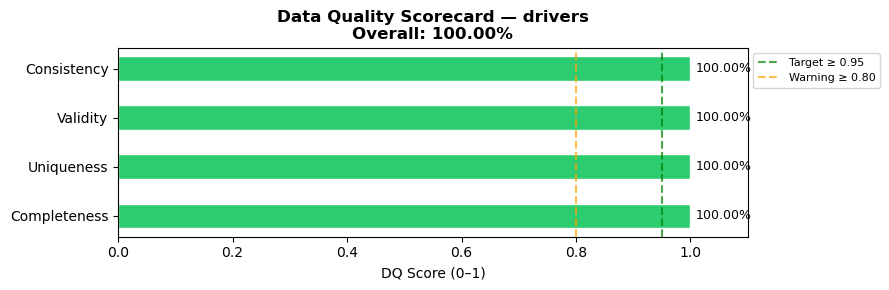


🏆 Overall Score — drivers: 100.00%  🟢 GREEN


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# DQA — drivers
# ─────────────────────────────────────────────────────────────────────────────

# Validity rules
drivers_validity_rules = {
    # hire_date must be a parseable date
    'hire_date'        : lambda s: pd.to_datetime(s, errors='coerce').notna(),
    # termination_date must be parseable if present
    'termination_date' : lambda s: pd.to_datetime(s, errors='coerce').notna(),
    # years_experience must be non-negative
    'years_experience' : lambda s: s >= 0,
    # employment_status must be one of the known values
    'employment_status': lambda s: s.isin(['Active', 'Terminated']),
}

# Consistency rules
drivers_consistency_rules = [
    # Terminated drivers must have a termination_date
    lambda df: ~((df['employment_status'] == 'Terminated') & df['termination_date'].isna()),
    # Active drivers must NOT have a termination_date
    lambda df: ~((df['employment_status'] == 'Active') & df['termination_date'].notna()),
    # termination_date must be after hire_date when present
    lambda df: (
        df['termination_date'].isna() |
        (pd.to_datetime(df['termination_date'], errors='coerce') >
         pd.to_datetime(df['hire_date'], errors='coerce'))
    ),
]

# Run DQA pipeline
report_drivers = run_dqa_pipeline(
    df                = drivers,
    table_name        = 'drivers',
    pk                = 'driver_id',
    completeness_cols = ['driver_id', 'first_name', 'last_name',
                         'hire_date', 'home_terminal', 'employment_status', 'years_experience'],
    uniqueness_cols   = ['driver_id'],
    validity_rules    = drivers_validity_rules,
    consistency_rules = drivers_consistency_rules,
)

# Print the scorecard in a readable format
sc = report_drivers.scorecard()[['Dimension','Score','Issues','Status','Details']]
print(f"{'Dimension':<15} {'Score':<8} {'Issues':<8} {'Status':<4}  {'Details'}")
print("-" * 80)
for _, row in sc.iterrows():
    print(f"{row['Dimension']:<15} {row['Score']:<8} {row['Issues']:<8} {row['Status']:<5}  {row['Details']}")

# Plot the scorecard for visual reference
report_drivers.plot_scorecard()

#### trucks

Dimension       Score    Issues   Status  Details
--------------------------------------------------------------------------------
Completeness    1.0      0        🟢      Missing per column: {}
Uniqueness      1.0      0        🟢      Duplicate rows on ['truck_id']: 0
Validity        1.0      0        🟢      model_year: 0 invalid | status: 0 invalid
Consistency     1.0      0        🟢      0 rows violate at least one consistency rule


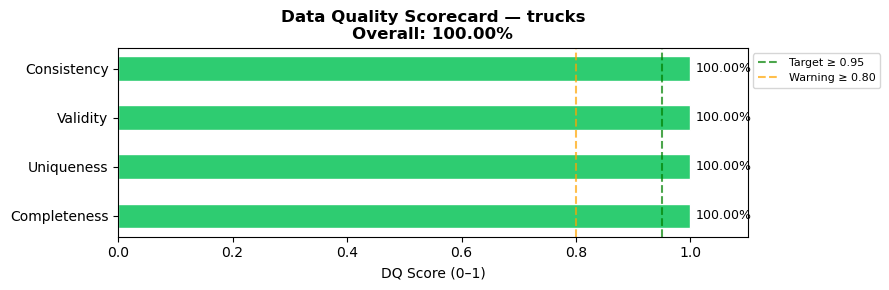


🏆 Overall Score — trucks: 100.00%  🟢 GREEN


In [38]:
# ─────────────────────────────────────────────────────────────────────────────
# DQA — trucks
# ─────────────────────────────────────────────────────────────────────────────

# Validity rules
trucks_validity_rules = {
    # model_year must be a realistic truck manufacturing year
    'model_year'  : lambda s: s.between(1990, 2025),
    # status must be one of the known values
    'status'      : lambda s: s.isin(['Active', 'Inactive', 'Maintenance'])
    # ,
}

# Consistency rules
trucks_consistency_rules = []

# Run DQA pipeline
report_trucks = run_dqa_pipeline(
    df                = trucks,
    table_name        = 'trucks',
    pk                = 'truck_id',
    completeness_cols = ['truck_id', 'make', 'model_year', 'status'],
    uniqueness_cols   = ['truck_id'],
    validity_rules    = trucks_validity_rules,
    consistency_rules = trucks_consistency_rules,
)

# Print the scorecard in a readable format
sc = report_trucks.scorecard()[['Dimension','Score','Issues','Status','Details']]
print(f"{'Dimension':<15} {'Score':<8} {'Issues':<8} {'Status':<4}  {'Details'}")
print("-" * 80)
for _, row in sc.iterrows():
    print(f"{row['Dimension']:<15} {row['Score']:<8} {row['Issues']:<8} {row['Status']:<5}  {row['Details']}")

# Plot the scorecard for visual reference
report_trucks.plot_scorecard()

#### trailers

Dimension       Score    Issues   Status  Details
--------------------------------------------------------------------------------
Completeness    1.0      0        🟢      Missing per column: {}
Uniqueness      1.0      0        🟢      Duplicate rows on ['trailer_id']: 0
Validity        1.0      0        🟢      trailer_type: 0 invalid | status: 0 invalid
Consistency     1.0      0        🟢      0 rows violate at least one consistency rule


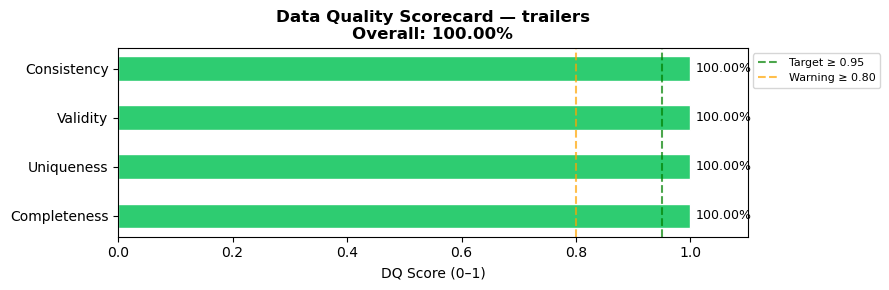


🏆 Overall Score — trailers: 100.00%  🟢 GREEN


In [39]:
# ─────────────────────────────────────────────────────────────────────────────
# DQA — trailers
# ─────────────────────────────────────────────────────────────────────────────

# Validity rules
trailers_validity_rules = {
    # trailer_type must be one of the two known types
    'trailer_type': lambda s: s.isin(['Refrigerated', 'Dry Van']),
    # status must be one of the known values
    'status'      : lambda s: s.isin(['Active']),
}

# Consistency rules
trailers_consistency_rules = []

# Run DQA pipeline
report_trailers = run_dqa_pipeline(
    df                = trailers,
    table_name        = 'trailers',
    pk                = 'trailer_id',
    completeness_cols = ['trailer_id', 'trailer_type', 'status'],
    uniqueness_cols   = ['trailer_id'],
    validity_rules    = trailers_validity_rules,
    consistency_rules = trailers_consistency_rules,
)

# Print scorecard
sc = report_trailers.scorecard()[['Dimension','Score','Issues','Status','Details']]
print(f"{'Dimension':<15} {'Score':<8} {'Issues':<8} {'Status':<4}  {'Details'}")
print("-" * 80)
for _, row in sc.iterrows():
    print(f"{row['Dimension']:<15} {row['Score']:<8} {row['Issues']:<8} {row['Status']:<5}  {row['Details']}")

report_trailers.plot_scorecard()

#### customers

Dimension       Score    Issues   Status  Details
--------------------------------------------------------------------------------
Completeness    1.0      0        🟢      Missing per column: {}
Uniqueness      1.0      0        🟢      Duplicate rows on ['customer_id']: 0
Validity        1.0      0        🟢      account_status: 0 invalid | customer_type: 0 invalid | primary_freight_type: 0 invalid
Consistency     1.0      0        🟢      0 rows violate at least one consistency rule


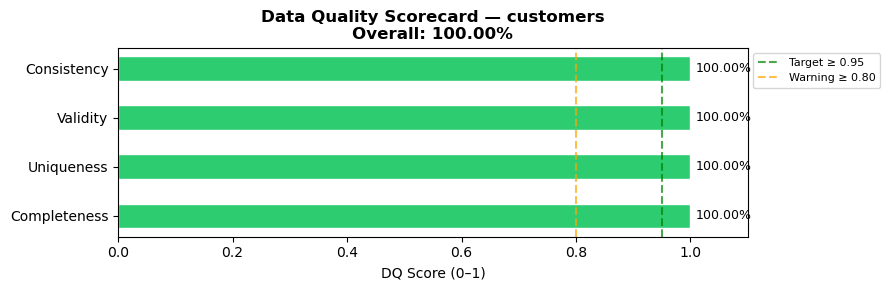


🏆 Overall Score — customers: 100.00%  🟢 GREEN


In [42]:
# ─────────────────────────────────────────────────────────────────────────────
# DQA — customers
# ─────────────────────────────────────────────────────────────────────────────

# Validity rules
customers_validity_rules = {
    # account_status must be one of the known values
    'account_status'      : lambda s: s.isin(['Active', 'Inactive']),
    # customer_type must be one of the known values — check raw data for exact values
    'customer_type'       : lambda s: s.isin(['Contract', 'Spot', 'Dedicated']),
    # primary_freight_type must be a known freight category
    'primary_freight_type': lambda s: s.isin(['Automotive', 'Food/Beverage', 'Retail', 
                                              'Electronics', 'Consumer Goods','General']),
}

# Consistency rules — no meaningful cross-column rules for customers
customers_consistency_rules = []

# Run DQA pipeline
report_customers = run_dqa_pipeline(
    df                = customers,
    table_name        = 'customers',
    pk                = 'customer_id',
    completeness_cols = ['customer_id', 'customer_name', 'customer_type',
                         'primary_freight_type', 'account_status'],
    uniqueness_cols   = ['customer_id'],
    validity_rules    = customers_validity_rules,
    consistency_rules = customers_consistency_rules,
)

# Print scorecard
sc = report_customers.scorecard()[['Dimension','Score','Issues','Status','Details']]
print(f"{'Dimension':<15} {'Score':<8} {'Issues':<8} {'Status':<4}  {'Details'}")
print("-" * 80)
for _, row in sc.iterrows():
    print(f"{row['Dimension']:<15} {row['Score']:<8} {row['Issues']:<8} {row['Status']:<5}  {row['Details']}")

report_customers.plot_scorecard()

#### facilities

Dimension       Score    Issues   Status  Details
--------------------------------------------------------------------------------
Completeness    1.0      0        🟢      Missing per column: {}
Uniqueness      1.0      0        🟢      Duplicate rows on ['facility_id']: 0
Validity        1.0      0        🟢      facility_type: 0 invalid | latitude: 0 invalid | longitude: 0 invalid
Consistency     1.0      0        🟢      0 rows violate at least one consistency rule


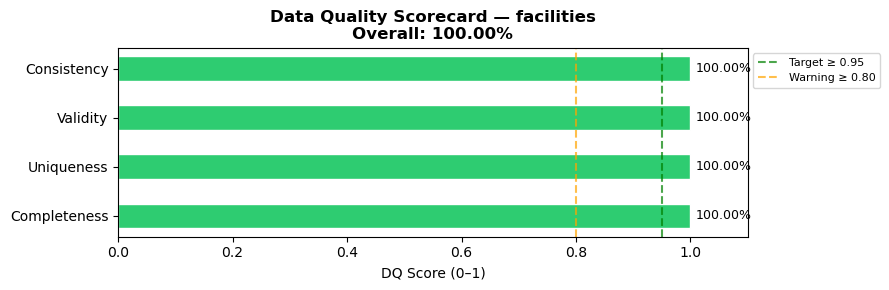


🏆 Overall Score — facilities: 100.00%  🟢 GREEN


In [44]:
# ─────────────────────────────────────────────────────────────────────────────
# DQA — facilities
# ─────────────────────────────────────────────────────────────────────────────

# Validity rules
facilities_validity_rules = {
    # facility_type must be one of the known values
    'facility_type': lambda s: s.isin(['Warehouse', 'Distribution Center', 'Terminal', 'Cross-Dock']),
    # latitude must be within valid geographic range
    'latitude' : lambda s: s.between(-90, 90),
    # longitude must be within valid geographic range
    'longitude': lambda s: s.between(-180, 180),
}

# Consistency rules
facilities_consistency_rules = [
    # latitude and longitude must both be present or both absent
    lambda df: df['latitude'].isna() == df['longitude'].isna(),
]

# Run DQA pipeline
report_facilities = run_dqa_pipeline(
    df                = facilities,
    table_name        = 'facilities',
    pk                = 'facility_id',
    completeness_cols = ['facility_id', 'facility_name', 'facility_type',
                         'city', 'state', 'latitude', 'longitude'],
    uniqueness_cols   = ['facility_id'],
    validity_rules    = facilities_validity_rules,
    consistency_rules = facilities_consistency_rules,
)

# Print scorecard
sc = report_facilities.scorecard()[['Dimension','Score','Issues','Status','Details']]
print(f"{'Dimension':<15} {'Score':<8} {'Issues':<8} {'Status':<4}  {'Details'}")
print("-" * 80)
for _, row in sc.iterrows():
    print(f"{row['Dimension']:<15} {row['Score']:<8} {row['Issues']:<8} {row['Status']:<5}  {row['Details']}")

report_facilities.plot_scorecard()

#### routes

Dimension       Score    Issues   Status  Details
--------------------------------------------------------------------------------
Completeness    1.0      0        🟢      Missing per column: {}
Uniqueness      1.0      0        🟢      Duplicate rows on ['route_id']: 0
Validity        1.0      0        🟢      typical_distance_miles: 0 invalid | typical_transit_days: 0 invalid | base_rate_per_mile: 0 invalid | fuel_surcharge_rate: 0 invalid
Consistency     1.0      0        🟢      0 rows violate at least one consistency rule


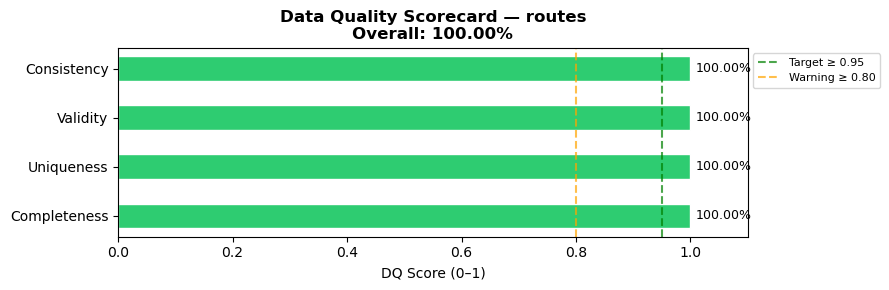


🏆 Overall Score — routes: 100.00%  🟢 GREEN


In [45]:
# ─────────────────────────────────────────────────────────────────────────────
# DQA — routes
# ─────────────────────────────────────────────────────────────────────────────

# Validity rules
routes_validity_rules = {
    # typical_distance_miles must be positive
    'typical_distance_miles': lambda s: s > 0,
    # typical_transit_days must be positive
    'typical_transit_days'  : lambda s: s > 0,
    # base_rate_per_mile must be positive
    'base_rate_per_mile'    : lambda s: s > 0,
    # fuel_surcharge_rate must be between 0 and 1 (percentage)
    'fuel_surcharge_rate'   : lambda s: s.between(0, 1),
}

# Consistency rules
routes_consistency_rules = [
    # origin and destination must not be the same city
    lambda df: df['origin_city'] != df['destination_city'],
]

# Run DQA pipeline
report_routes = run_dqa_pipeline(
    df                = routes,
    table_name        = 'routes',
    pk                = 'route_id',
    completeness_cols = ['route_id', 'origin_city', 'origin_state',
                         'destination_city', 'destination_state',
                         'typical_distance_miles', 'typical_transit_days',
                         'base_rate_per_mile', 'fuel_surcharge_rate'],
    uniqueness_cols   = ['route_id'],
    validity_rules    = routes_validity_rules,
    consistency_rules = routes_consistency_rules,
)

# Print scorecard
sc = report_routes.scorecard()[['Dimension','Score','Issues','Status','Details']]
print(f"{'Dimension':<15} {'Score':<8} {'Issues':<8} {'Status':<4}  {'Details'}")
print("-" * 80)
for _, row in sc.iterrows():
    print(f"{row['Dimension']:<15} {row['Score']:<8} {row['Issues']:<8} {row['Status']:<5}  {row['Details']}")

report_routes.plot_scorecard()

#### loads

Dimension       Score    Issues   Status  Details
--------------------------------------------------------------------------------
Completeness    1.0      0        🟢      Missing per column: {}
Uniqueness      1.0      0        🟢      Duplicate rows on ['load_id']: 0
Validity        1.0      0        🟢      load_type: 0 invalid | revenue: 0 invalid | fuel_surcharge: 0 invalid | accessorial_charges: 0 invalid | weight_lbs: 0 invalid | booking_type: 0 invalid | load_date: 0 invalid
Consistency     1.0      0        🟢      0 rows violate at least one consistency rule


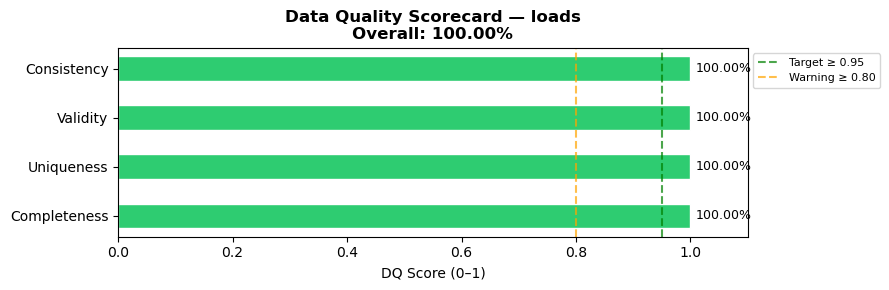


🏆 Overall Score — loads: 100.00%  🟢 GREEN


In [48]:
# ─────────────────────────────────────────────────────────────────────────────
# DQA — loads
# ─────────────────────────────────────────────────────────────────────────────

# Validity rules
loads_validity_rules = {
    # load_type must be one of the known values
    'load_type'         : lambda s: s.isin(['Refrigerated', 'Dry Van']),
    # revenue must be positive
    'revenue'            : lambda s: s > 0,
    # fuel_surcharge must be non-negative
    'fuel_surcharge'     : lambda s: s >= 0,
    # accessorial_charges must be non-negative
    'accessorial_charges': lambda s: s >= 0,
    # weight_lbs must be positive
    'weight_lbs'         : lambda s: s > 0,
    # booking_type must be one of the known values
    'booking_type'       : lambda s: s.isin(['Contract', 'Spot', 'Dedicated']),
    # load_date must be parseable and within 2022-2024
    'load_date'          : lambda s: pd.to_datetime(s, errors='coerce').between(
                                     pd.Timestamp('2022-01-01'), pd.Timestamp('2024-12-31'))
}

# Consistency rules
loads_consistency_rules = [
    # customer_id must exist in customers table
    lambda df: df['customer_id'].isin(customers['customer_id']),
    # route_id must exist in routes table
    lambda df: df['route_id'].isin(routes['route_id']),
]

# Run DQA pipeline
report_loads = run_dqa_pipeline(
    df                = loads,
    table_name        = 'loads',
    pk                = 'load_id',
    completeness_cols = ['load_id', 'customer_id', 'route_id', 'load_date',
                         'load_type', 'weight_lbs', 'revenue',
                         'fuel_surcharge', 'accessorial_charges', 'booking_type'],
    uniqueness_cols   = ['load_id'],
    validity_rules    = loads_validity_rules,
    consistency_rules = loads_consistency_rules,
)

# Print scorecard
sc = report_loads.scorecard()[['Dimension','Score','Issues','Status','Details']]
print(f"{'Dimension':<15} {'Score':<8} {'Issues':<8} {'Status':<4}  {'Details'}")
print("-" * 80)
for _, row in sc.iterrows():
    print(f"{row['Dimension']:<15} {row['Score']:<8} {row['Issues']:<8} {row['Status']:<5}  {row['Details']}")

report_loads.plot_scorecard()

#### trips

Dimension       Score    Issues   Status  Details
--------------------------------------------------------------------------------
Completeness    0.9946   5066     🟢      Missing per column: {'driver_id': 1714, 'truck_id': 1672, 'trailer_id': 1680}
Uniqueness      1.0      0        🟢      Duplicate rows on ['trip_id']: 0
Validity        1.0      0        🟢      dispatch_date: 0 invalid | actual_distance_miles: 0 invalid | fuel_gallons_used: 0 invalid | actual_duration_hours: 0 invalid | average_mpg: 0 invalid | idle_time_hours: 0 invalid
Consistency     1.0      0        🟢      0 rows violate at least one consistency rule


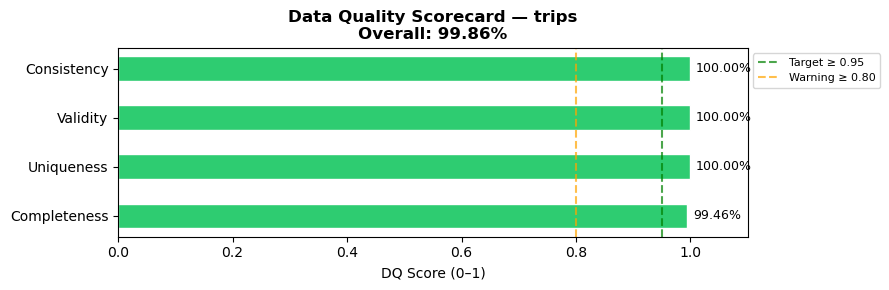


🏆 Overall Score — trips: 99.86%  🟢 GREEN


In [50]:
# ─────────────────────────────────────────────────────────────────────────────
# DQA — trips
# ─────────────────────────────────────────────────────────────────────────────

# Merge trips with loads to enable cross-table consistency checks
trips_loads = trips.merge(loads[['load_id', 'load_date', 'customer_id', 'route_id']],
                          on='load_id', how='left')

# Validity rules
trips_validity_rules = {
    # dispatch_date must be within simulation window 2022-2024
    'dispatch_date'        : lambda s: pd.to_datetime(s, errors='coerce').between(
                                       pd.Timestamp('2022-01-01'), pd.Timestamp('2024-12-31')),
    # actual_distance_miles must be positive
    'actual_distance_miles': lambda s: s > 0,
    # fuel_gallons_used must be positive
    'fuel_gallons_used'    : lambda s: s > 0,
    # actual_duration_hours must be positive
    'actual_duration_hours': lambda s: s > 0,
    # average_mpg must be positive
    'average_mpg'          : lambda s: s > 0,
    # idle_time_hours must be non-negative
    'idle_time_hours'      : lambda s: s >= 0,
}

# Consistency rules
trips_consistency_rules = [
    # load_id must exist in loads table
    lambda df: df['load_id'].isin(loads['load_id']),
    # driver_id must exist in drivers table if not null
    lambda df: df['driver_id'].isna() | df['driver_id'].isin(drivers['driver_id']),
    # truck_id must exist in trucks table if not null
    lambda df: df['truck_id'].isna() | df['truck_id'].isin(trucks['truck_id']),
    # trailer_id must exist in trailers table if not null
    lambda df: df['trailer_id'].isna() | df['trailer_id'].isin(trailers['trailer_id']),
    # Check 1: dispatch_date must be on or after load_date
    lambda df: (
        pd.to_datetime(trips_loads['dispatch_date'], errors='coerce') >=
        pd.to_datetime(trips_loads['load_date'], errors='coerce')),
    # Check 2: dispatch_date equals load_date (used to determine if load_date is redundant)
    lambda df: (
        pd.to_datetime(trips_loads['dispatch_date'], errors='coerce').dt.date ==
        pd.to_datetime(trips_loads['load_date'], errors='coerce').dt.date),
]

# Run DQA pipeline
report_trips = run_dqa_pipeline(
    df                = trips,
    table_name        = 'trips',
    pk                = 'trip_id',
    completeness_cols = ['trip_id', 'load_id', 'driver_id', 'truck_id',
                         'trailer_id', 'dispatch_date', 'actual_distance_miles',
                         'fuel_gallons_used', 'actual_duration_hours',
                         'average_mpg', 'idle_time_hours'],
    uniqueness_cols   = ['trip_id'],
    validity_rules    = trips_validity_rules,
    consistency_rules = trips_consistency_rules,
)

# Print scorecard
sc = report_trips.scorecard()[['Dimension','Score','Issues','Status','Details']]
print(f"{'Dimension':<15} {'Score':<8} {'Issues':<8} {'Status':<4}  {'Details'}")
print("-" * 80)
for _, row in sc.iterrows():
    print(f"{row['Dimension']:<15} {row['Score']:<8} {row['Issues']:<8} {row['Status']:<5}  {row['Details']}")

report_trips.plot_scorecard()

#### delivery_events

Dimension       Score    Issues   Status  Details
--------------------------------------------------------------------------------
Completeness    1.0      0        🟢      Missing per column: {}
Uniqueness      1.0      0        🟢      Duplicate rows on ['event_id']: 0
Validity        1.0      0        🟢      event_type: 0 invalid | scheduled_datetime: 0 invalid | actual_datetime: 0 invalid | detention_minutes: 0 invalid
Consistency     1.0      0        🟢      0 rows violate at least one consistency rule


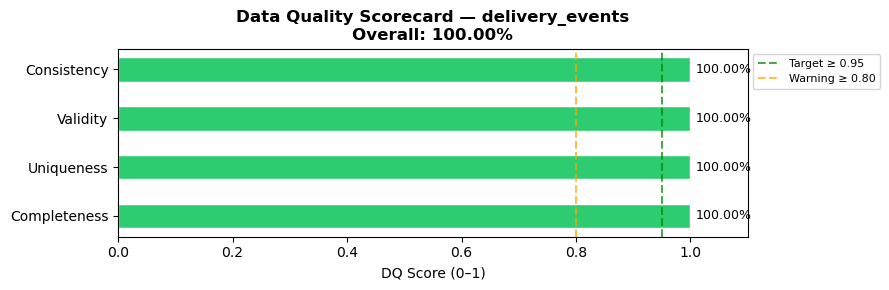


🏆 Overall Score — delivery_events: 100.00%  🟢 GREEN


In [57]:
# ─────────────────────────────────────────────────────────────────────────────
# DQA — delivery_events
# ─────────────────────────────────────────────────────────────────────────────

# Validity rules
delivery_events_validity_rules = {
    # event_type must be pickup or delivery
    'event_type'        : lambda s: s.isin(['Pickup', 'Delivery']),
    # scheduled_datetime: pickups must be within 2022-2024, deliveries can spill into 2025
    'scheduled_datetime': lambda s: pd.to_datetime(s, errors='coerce').notna(),
    # actual_datetime: same logic, just check parseable
    'actual_datetime'   : lambda s: pd.to_datetime(s, errors='coerce').notna(),
    # detention_minutes must be non-negative
    'detention_minutes' : lambda s: s >= 0,
}

# Consistency rules
delivery_events_consistency_rules = [
    # trip_id must exist in trips table
    lambda df: df['trip_id'].isin(trips['trip_id']),
    # facility_id must exist in facilities table
    lambda df: df['facility_id'].isin(facilities['facility_id']),
    # pickup scheduled_datetime must be within 2022-2024
    lambda df: (
        (df['event_type'] != 'pickup') |
        pd.to_datetime(df['scheduled_datetime'], errors='coerce').between(
        pd.Timestamp('2022-01-01'), pd.Timestamp('2024-12-31 23:59:59'))),
]

# Run DQA pipeline
report_delivery_events = run_dqa_pipeline(
    df                = delivery_events,
    table_name        = 'delivery_events',
    pk                = 'event_id',
    completeness_cols = ['event_id', 'trip_id', 'facility_id',
                         'event_type', 'scheduled_datetime', 'actual_datetime',
                         'detention_minutes'],
    uniqueness_cols   = ['event_id'],
    validity_rules    = delivery_events_validity_rules,
    consistency_rules = delivery_events_consistency_rules,
)

# Print scorecard
sc = report_delivery_events.scorecard()[['Dimension','Score','Issues','Status','Details']]
print(f"{'Dimension':<15} {'Score':<8} {'Issues':<8} {'Status':<4}  {'Details'}")
print("-" * 80)
for _, row in sc.iterrows():
    print(f"{row['Dimension']:<15} {row['Score']:<8} {row['Issues']:<8} {row['Status']:<5}  {row['Details']}")

report_delivery_events.plot_scorecard()

In [60]:
# Check what dates are outside the 2022-2024 window
sched = pd.to_datetime(delivery_events['scheduled_datetime'], errors='coerce')
actual = pd.to_datetime(delivery_events['actual_datetime'], errors='coerce')

print("Scheduled datetime out of range:")
print(sched[~sched.between('2022-01-01', '2024-12-31 23:59:59')].value_counts())

print("\nActual datetime out of range:")
print(actual[~actual.between('2022-01-01', '2024-12-31 23:59:59')].value_counts())

Scheduled datetime out of range:
scheduled_datetime
2025-01-01 18:42:08.417630    1
2025-01-01 23:01:57.509915    1
2025-01-01 17:09:24.910471    1
2025-01-01 02:11:10.344813    1
2025-01-02 14:02:23.722046    1
                             ..
2025-01-01 03:42:41.854635    1
2025-01-02 08:57:55.802565    1
2025-01-02 09:52:10.858227    1
2025-01-01 00:14:53.207882    1
2025-01-01 07:30:59.579843    1
Name: count, Length: 77, dtype: int64

Actual datetime out of range:
actual_datetime
2025-01-01 17:30:10.425916    1
2025-01-01 21:53:54.841785    1
2025-01-01 22:22:54.085590    1
2025-01-01 00:14:57.515900    1
2025-01-01 04:46:45.038278    1
                             ..
2025-01-01 15:01:24.296150    1
2025-01-01 04:05:37.281360    1
2025-01-02 12:56:36.342240    1
2025-01-02 11:10:55.507171    1
2025-01-01 13:06:58.729240    1
Name: count, Length: 86, dtype: int64


In [61]:
# Check event_type for out of range scheduled datetimes
sched = pd.to_datetime(delivery_events['scheduled_datetime'], errors='coerce')
out_of_range = delivery_events[~sched.between('2022-01-01', '2024-12-31 23:59:59')]

print("Event types for out-of-range scheduled_datetime:")
print(out_of_range['event_type'].value_counts())

print("\nEvent types for out-of-range actual_datetime:")
actual = pd.to_datetime(delivery_events['actual_datetime'], errors='coerce')
out_of_range_actual = delivery_events[~actual.between('2022-01-01', '2024-12-31 23:59:59')]
print(out_of_range_actual['event_type'].value_counts())

Event types for out-of-range scheduled_datetime:
event_type
Delivery    77
Name: count, dtype: int64

Event types for out-of-range actual_datetime:
event_type
Delivery    86
Name: count, dtype: int64


#### fuel_purchases

Dimension       Score    Issues   Status  Details
--------------------------------------------------------------------------------
Completeness    1.0      0        🟢      Missing per column: {}
Uniqueness      1.0      0        🟢      Duplicate rows on ['fuel_purchase_id']: 0
Validity        1.0      0        🟢      gallons: 0 invalid | price_per_gallon: 0 invalid | total_cost: 0 invalid
Consistency     1.0      0        🟢      0 rows violate at least one consistency rule


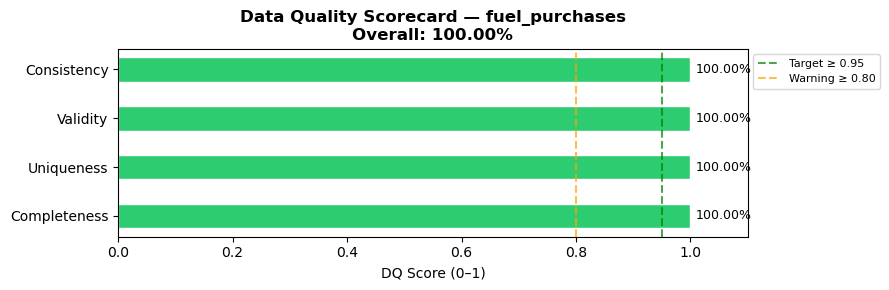


🏆 Overall Score — fuel_purchases: 100.00%  🟢 GREEN


In [62]:
# ─────────────────────────────────────────────────────────────────────────────
# DQA — fuel_purchases
# ─────────────────────────────────────────────────────────────────────────────

# Validity rules
fuel_purchases_validity_rules = {
    # gallons must be positive
    'gallons'        : lambda s: s > 0,
    # price_per_gallon must be positive
    'price_per_gallon': lambda s: s > 0,
    # total_cost must be positive
    'total_cost'     : lambda s: s > 0,
}

# Consistency rules
fuel_purchases_consistency_rules = [
    # trip_id must exist in trips table
    lambda df: df['trip_id'].isin(trips['trip_id']),
    # total_cost must equal gallons * price_per_gallon (within rounding tolerance)
    lambda df: (
        (df['total_cost'] - df['gallons'] * df['price_per_gallon']).abs() < 0.01
    ),
]

# Run DQA pipeline
report_fuel_purchases = run_dqa_pipeline(
    df                = fuel_purchases,
    table_name        = 'fuel_purchases',
    pk                = 'fuel_purchase_id',
    completeness_cols = ['fuel_purchase_id', 'trip_id', 'gallons',
                         'price_per_gallon', 'total_cost'],
    uniqueness_cols   = ['fuel_purchase_id'],
    validity_rules    = fuel_purchases_validity_rules,
    consistency_rules = fuel_purchases_consistency_rules,
)

# Print scorecard
sc = report_fuel_purchases.scorecard()[['Dimension','Score','Issues','Status','Details']]
print(f"{'Dimension':<15} {'Score':<8} {'Issues':<8} {'Status':<4}  {'Details'}")
print("-" * 80)
for _, row in sc.iterrows():
    print(f"{row['Dimension']:<15} {row['Score']:<8} {row['Issues']:<8} {row['Status']:<5}  {row['Details']}")

report_fuel_purchases.plot_scorecard()

### 3.5 Multi-Table DQ Score Comparison

✅ Combined scorecard saved to data/output/dq_scorecard_all_tables.csv

─────────────────────────────────────────────
  Table                Overall Score   Status
─────────────────────────────────────────────
  drivers              100.00%         🟢
  trucks               100.00%         🟢
  trailers             100.00%         🟢
  customers            100.00%         🟢
  facilities           100.00%         🟢
  routes               100.00%         🟢
  loads                100.00%         🟢
  trips                99.86%          🟢
  delivery_events      100.00%         🟢
  fuel_purchases       100.00%         🟢
─────────────────────────────────────────────


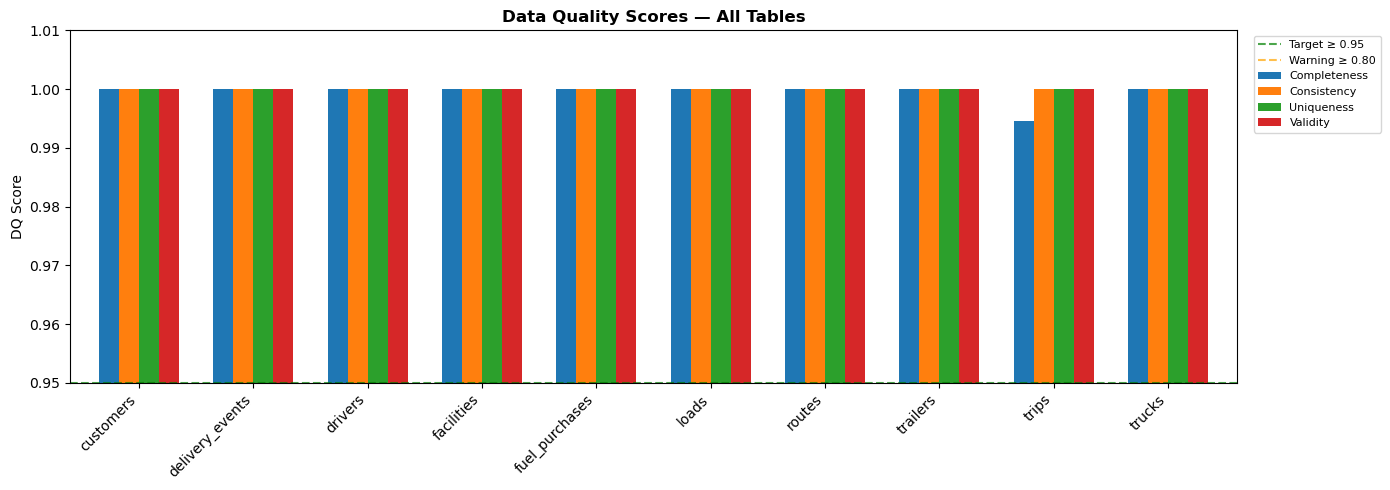

In [63]:
# ─────────────────────────────────────────────────────────────────────────────
# Multi-table DQ score comparison
# Combines scorecards from all 10 tables into a single comparison chart
# ─────────────────────────────────────────────────────────────────────────────

# Collect all reports
all_reports = {
    'drivers'        : report_drivers,
    'trucks'         : report_trucks,
    'trailers'       : report_trailers,
    'customers'      : report_customers,
    'facilities'     : report_facilities,
    'routes'         : report_routes,
    'loads'          : report_loads,
    'trips'          : report_trips,
    'delivery_events': report_delivery_events,
    'fuel_purchases' : report_fuel_purchases,
}

# Combine all scorecards
combined = pd.concat(
    [r.scorecard() for r in all_reports.values()],
    ignore_index=True
)

# Save combined scorecard to CSV
combined.to_csv(OUTPUT_PATH + 'dq_scorecard_all_tables.csv', index=False)
print("✅ Combined scorecard saved to data/output/dq_scorecard_all_tables.csv")

# Overall scores per table
print(f"\n{'─'*45}")
print(f"  {'Table':<20} {'Overall Score':<15} {'Status'}")
print(f"{'─'*45}")
for name, report in all_reports.items():
    score  = report.overall_score()
    status = '🟢' if score >= 0.95 else ('🟡' if score >= 0.80 else '🔴')
    print(f"  {name:<20} {score:<15.2%} {status}")
print(f"{'─'*45}")

# Multi-table comparison chart
pivot = combined.pivot_table(index='Dimension', columns='Table', values='Score')

fig, ax = plt.subplots(figsize=(14, 5))
pivot.T.plot(kind='bar', ax=ax, width=0.7)
ax.axhline(0.95, color='green',  linestyle='--', linewidth=1.5,
           alpha=0.7, label='Target ≥ 0.95')
ax.axhline(0.80, color='orange', linestyle='--', linewidth=1.5,
           alpha=0.7, label='Warning ≥ 0.80')
ax.set_ylim(0.95, 1.01)
ax.set_ylabel('DQ Score')
ax.set_xlabel('')
ax.set_title('Data Quality Scores — All Tables', fontweight='bold')
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Missing Values, Outlier Detection & Cleaning Pipeline

This section implements the full data preparation pipeline in three stages:
1. **Missing value analysis** - classify mechanism (MCAR/MAR/MNAR) and decide strategy
2. **Outlier detection** - IQR, Modified Z-score, Isolation Forest with consensus strategy
3. **Cleaning pipeline** - structured, auditable transformations with before/after scoring

In [64]:
# ─────────────────────────────────────────────────────────────────────────────
# Install and import additional dependencies
# ─────────────────────────────────────────────────────────────────────────────

import subprocess
subprocess.run(['pip', 'install', 'recordlinkage', 'statsmodels', '--quiet'])

from scipy import stats
from scipy.stats import chi2_contingency
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.impute import KNNImputer
import statsmodels.api as sm
import recordlinkage
import warnings
from datetime import datetime
from copy import deepcopy

warnings.filterwarnings('ignore')

print("✅ Dependencies loaded")

✅ Dependencies loaded


### 4.1 Class Definitions

#### MissingnessAnalyzer
Classifies missing value mechanisms (MCAR/MAR/MNAR) using statistical tests.
Adapted from Lesson 2 course materials.

In [65]:
class MissingnessAnalyzer:
    # Define a class for structured analysis of missing-value patterns and mechanisms.

    """
    Structured analysis of missing value patterns and mechanisms.
    Provides quantitative tests to classify MCAR / MAR / MNAR.
    """
    # Document the purpose of the class:
    # it summarizes missingness and provides statistical tests or proxy checks
    # to support missingness classification.

    def __init__(self, df: pd.DataFrame, table_name: str):
        # Initialize the class with a DataFrame and a logical table name.

        self.df         = df.copy()
        # Store a copy of the input DataFrame to avoid modifying the original dataset.

        self.table_name = table_name
        # Store the table name for reporting and identification purposes.

        self.results    = {}
        # Initialize an empty dictionary to store analysis results if needed later.

    def summary(self) -> pd.DataFrame:
        # Define a method that returns a column-level missingness summary.

        """Basic missingness summary per column."""
        # Describe the purpose of this method.

        miss  = self.df.isnull().sum()
        # Count the number of missing values in each column.

        total = len(self.df)
        # Store the total number of rows in the dataset.

        pct   = (miss / total * 100).round(2)
        # Compute the percentage of missing values per column and round to 2 decimals.

        result = pd.DataFrame({
            'missing_count': miss,
            # Store the absolute number of missing values per column.

            'missing_pct'  : pct,
            # Store the percentage of missing values per column.

            'present_count': total - miss,
            # Store the number of non-missing values per column.

            'dtype'        : self.df.dtypes
            # Store the data type of each column.
        })
        # Build a summary DataFrame combining missing counts, percentages, present counts, and dtypes.

        result['status'] = result['missing_pct'].apply(
            lambda p: '🟢 OK' if p == 0 else ('🟡 Moderate' if p < 10 else '🔴 High')
        )
        # Add a qualitative status label based on missing percentage:
        # - 0% missing → OK
        # - less than 10% → Moderate
        # - 10% or more → High

        return result[result['missing_count'] > 0].sort_values('missing_pct', ascending=False)
        # Return only columns that actually contain missing values,
        # sorted from highest to lowest missing percentage.

    def test_mcar_chi2(self, col: str, group_col: str) -> dict:
        # Define a chi-squared independence test to evaluate whether missingness in one column
        # is related to an observed grouping variable.

        """
        Chi-squared test of independence:
        H0: missingness in `col` is independent of `group_col` (MCAR)
        Low p-value → reject H0 → likely MAR (depends on group_col)
        """
        # Explain the statistical interpretation of the test.

        temp = pd.DataFrame({
            'is_missing': self.df[col].isna().astype(int),
            # Create a binary indicator: 1 if the value is missing, 0 otherwise.

            'group'     : self.df[group_col].fillna('__MISSING__')
            # Copy the grouping column and replace any missing group values
            # with a placeholder so they can still be included in the test.
        })
        # Build a temporary DataFrame containing missingness status and grouping variable.

        contingency = pd.crosstab(temp['is_missing'], temp['group'])
        # Create a contingency table crossing missingness with group categories.

        chi2, p_value, dof, _ = chi2_contingency(contingency)
        # Run the chi-squared test of independence on the contingency table.

        return {
            'col'       : col,
            # Return the target column name.

            'group_col' : group_col,
            # Return the grouping column name.

            'chi2'      : round(chi2, 4),
            # Return the chi-squared test statistic, rounded to 4 decimals.

            'p_value'   : round(p_value, 6),
            # Return the p-value, rounded to 6 decimals.

            'dof'       : dof,
            # Return the degrees of freedom of the chi-squared test.

            'verdict'   : ('MAR — missingness depends on ' + group_col)
                           if p_value < 0.05 else 'Cannot reject MCAR',
            # Return an interpretation:
            # - low p-value → missingness depends on the observed group (likely MAR)
            # - otherwise → no evidence against MCAR

            'significance': '***' if p_value < 0.001 else ('**' if p_value < 0.01 else
                           ('*' if p_value < 0.05 else 'ns'))
            # Return a significance marker for easier interpretation.
        }

    def test_mar_logistic(self, col: str, candidate_predictors: list) -> dict:
        # Define a logistic regression test to evaluate whether missingness in one column
        # can be predicted from observed numeric variables.

        """
        Logistic regression: can observed columns predict missingness in `col`?
        High pseudo-R² → strong MAR signal.
        """
        # Explain the logic of the test.

        y = self.df[col].isna().astype(int)
        # Create the binary response variable:
        # 1 if the target column is missing, 0 otherwise.

        predictors = [c for c in candidate_predictors
                      if c in self.df.columns and c != col
                      and pd.api.types.is_numeric_dtype(self.df[c])]
        # Keep only valid predictor columns:
        # - must exist in the DataFrame
        # - must be different from the target column
        # - must be numeric

        X_raw = self.df[predictors].fillna(self.df[predictors].median())
        # Fill missing values in the predictor matrix with column medians
        # so the logistic model can be fitted.

        X     = StandardScaler().fit_transform(X_raw)
        # Standardize predictors to zero mean and unit variance.

        X_sm  = sm.add_constant(X)
        # Add an intercept term for the logistic regression model.

        try:
            # Start a protected block to catch model-fitting errors.

            model     = sm.Logit(y, X_sm).fit(disp=False)
            # Fit a logistic regression model predicting missingness.

            pseudo_r2 = model.prsquared
            # Extract McFadden pseudo-R² as a measure of predictive strength.

            verdict   = ('Strong MAR signal' if pseudo_r2 > 0.1 else
                         ('Weak MAR signal'  if pseudo_r2 > 0.02 else 'Consistent with MCAR'))
            # Interpret the pseudo-R²:
            # - above 0.1 → strong evidence that missingness depends on observed variables
            # - above 0.02 → weak evidence
            # - otherwise → weak or no MAR signal

            return {'col': col, 'predictors': predictors,
                    'pseudo_r2': round(pseudo_r2, 4), 'verdict': verdict}
            # Return the tested column, predictors used, pseudo-R², and interpretation.

        except Exception as e:
            # Catch errors such as singular matrix, no predictors, or convergence issues.

            return {'col': col, 'predictors': predictors, 'pseudo_r2': None, 'verdict': f'Test failed: {e}'}
            # Return a failure message instead of interrupting execution.

    def test_mnar_correlation(self, col: str, numeric_cols: list) -> dict:
        # Define a proxy analysis for possible MNAR behavior by comparing other numeric variables
        # between rows where the target column is missing and rows where it is present.

        """
        Proxy MNAR test: compare mean of other numeric columns
        between rows where `col` is missing vs present.
        Large differences suggest MNAR (the missing values are 'special').
        """
        # Explain the purpose and limitation of this proxy test.

        present = self.df[self.df[col].notna()]
        # Select rows where the target column is present.

        missing = self.df[self.df[col].isna()]
        # Select rows where the target column is missing.

        diffs   = {}
        # Initialize a dictionary to store comparison results for each numeric column.

        for nc in numeric_cols:
            # Iterate over candidate numeric comparison columns.

            if nc == col or nc not in self.df.columns: continue
            # Skip the target column itself or any non-existing column.

            if not pd.api.types.is_numeric_dtype(self.df[nc]): continue
            # Skip non-numeric columns.

            mu_pres = present[nc].mean()
            # Compute the mean of the comparison column among rows where the target is present.

            mu_miss = missing[nc].mean()
            # Compute the mean of the comparison column among rows where the target is missing.

            if pd.notna(mu_pres) and pd.notna(mu_miss):
                # Continue only if both means are valid numbers.

                _, pval = stats.ttest_ind(present[nc].dropna(), missing[nc].dropna(),
                                          equal_var=False)
                # Run Welch’s t-test to compare the distributions between the two groups.

                diffs[nc] = {'mean_present': round(mu_pres, 2),
                             # Store the mean for rows where the target is present.

                             'mean_missing': round(mu_miss, 2),
                             # Store the mean for rows where the target is missing.

                             'p_value': round(pval, 4),
                             # Store the p-value of the comparison.

                             'significant': pval < 0.05}
                             # Mark whether the difference is statistically significant.

        mnar_signal = any(v['significant'] for v in diffs.values())
        # Check whether at least one comparison shows a significant difference.

        return {'col': col, 'comparisons': diffs,
                # Return all pairwise comparison results.

                'mnar_signal': mnar_signal,
                # Return a boolean indicating whether any proxy MNAR signal was detected.

                'verdict': ('Possible MNAR — significant group differences' if mnar_signal
                           else 'No MNAR signal detected')}
                # Return a human-readable interpretation of the proxy analysis.

print('✅ MissingnessAnalyzer class defined')
# Print a confirmation message indicating that the class has been successfully defined

✅ MissingnessAnalyzer class defined


#### OutlierDetector
Detects outliers using IQR, Modified Z-score, and Isolation Forest.
Consensus strategy flags rows caught by ≥2 methods.
Adapted from Lesson 2 course materials.

In [66]:
class OutlierDetector:
    # Define a class for structured and repeatable outlier detection on Data Warehouse tables.

    """
    Structured, repeatable outlier detection for DW tables.
    Supports univariate (IQR, Z-score, Modified Z-score) and
    multivariate (Isolation Forest, LOF) methods.
    """
    # Document the purpose of the class:
    # it applies multiple outlier detection methods and stores both row-level flags and summary results.

    def __init__(self, df: pd.DataFrame, table_name: str):
        # Initialize the class with a DataFrame and a table name.

        self.df         = df.copy()
        # Store a copy of the input DataFrame to avoid modifying the original dataset.

        self.table_name = table_name
        # Store the table name for reporting purposes.

        self.flags      = pd.DataFrame(False, index=df.index,
                                       columns=['iqr','zscore','mod_zscore',
                                                'isolation_forest','lof'])
        # Initialize a boolean DataFrame that will store row-level outlier flags
        # for each detection method. All rows start as False (not flagged).

        self.results    = {}
        # Initialize an empty dictionary to store summary results for each method.

    # ── IQR fence ─────────────────────────────────────────────────────────
    def detect_iqr(self, cols: list, multiplier: float = 1.5):
        # Define a univariate outlier detector based on the IQR rule.

        flag = pd.Series(False, index=self.df.index)
        # Initialize a boolean Series to accumulate row-level outlier flags across columns.

        details = {}
        # Initialize a dictionary to store per-column IQR details.

        for col in cols:
            # Iterate over each candidate column.

            if col not in self.df.columns: continue
            # Skip the column if it is not present in the DataFrame.

            s  = self.df[col].dropna()
            # Remove missing values before computing quartiles.

            Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
            # Compute the first and third quartiles.

            IQR    = Q3 - Q1
            # Compute the interquartile range.

            lo, hi = Q1 - multiplier * IQR, Q3 + multiplier * IQR
            # Compute lower and upper IQR fences.

            col_flag = ((self.df[col] < lo) | (self.df[col] > hi)) & self.df[col].notna()
            # Flag rows where the value falls outside the IQR fences
            # and is not missing.

            flag |= col_flag
            # Accumulate outlier flags across columns using logical OR.

            details[col] = {'Q1': round(Q1,2), 'Q3': round(Q3,2), 'IQR': round(IQR,2),
                            'lower_fence': round(lo,2), 'upper_fence': round(hi,2),
                            'outlier_count': int(col_flag.sum())}
            # Store per-column statistics and number of detected outliers.

        self.flags['iqr'] = flag
        # Save the final row-level IQR outlier flags.

        self.results['iqr'] = {'total_flagged': int(flag.sum()),
                               'pct': round(flag.mean()*100, 2), 'details': details}
        # Save the total number and percentage of flagged rows, plus detailed per-column info.

        return self
        # Return self to allow method chaining.

    # ── Z-score ────────────────────────────────────────────────────────────
    def detect_zscore(self, cols: list, threshold: float = 3.0):
        # Define a univariate outlier detector based on standard Z-scores.

        flag = pd.Series(False, index=self.df.index)
        # Initialize a boolean Series for accumulated row-level flags.

        details = {}
        # Initialize a dictionary to store per-column Z-score details.

        for col in cols:
            # Iterate over each candidate column.

            if col not in self.df.columns: continue
            # Skip missing columns.

            s         = self.df[col].fillna(self.df[col].mean())
            # Fill missing values with the column mean so Z-scores can be computed.

            z         = np.abs(stats.zscore(s))
            # Compute absolute Z-scores for the column.

            col_flag  = pd.Series(z > threshold, index=self.df.index) & self.df[col].notna()
            # Flag rows whose absolute Z-score exceeds the threshold
            # and whose original value is not missing.

            flag |= col_flag
            # Accumulate row-level flags across columns.

            details[col] = {'mean': round(self.df[col].mean(), 2),
                            'std' : round(self.df[col].std(), 2),
                            'max_z': round(z.max(), 2),
                            'outlier_count': int(col_flag.sum())}
            # Store summary statistics and number of outliers for the column.

        self.flags['zscore'] = flag
        # Save final row-level Z-score flags.

        self.results['zscore'] = {'total_flagged': int(flag.sum()),
                                  'pct': round(flag.mean()*100, 2), 'details': details}
        # Save overall Z-score summary results.

        return self
        # Return self to allow method chaining.

    # ── Modified Z-score (robust — uses median) ───────────────────────────
    def detect_modified_zscore(self, cols: list, threshold: float = 3.5):
        # Define a robust univariate outlier detector based on median and MAD.

        flag = pd.Series(False, index=self.df.index)
        # Initialize a boolean Series for accumulated row-level flags.

        details = {}
        # Initialize a dictionary to store per-column Modified Z-score details.

        for col in cols:
            # Iterate over each candidate column.

            if col not in self.df.columns: continue
            # Skip missing columns.

            s      = self.df[col].dropna()
            # Remove missing values before computing robust statistics.

            median = s.median()
            # Compute the median of the column.

            mad    = (s - median).abs().median()
            # Compute the Median Absolute Deviation (MAD).

            if mad == 0: continue
            # Skip the column if MAD is zero to avoid division by zero.

            mod_z  = 0.6745 * (self.df[col] - median) / mad
            # Compute the Modified Z-score using the standard scaling constant.

            col_flag = (mod_z.abs() > threshold) & self.df[col].notna()
            # Flag rows whose absolute Modified Z-score exceeds the threshold
            # and whose original value is not missing.

            flag |= col_flag
            # Accumulate row-level flags across columns.

            details[col] = {'median': round(median, 2), 'MAD': round(mad, 2),
                            'max_mod_z': round(mod_z.abs().max(), 2),
                            'outlier_count': int(col_flag.sum())}
            # Store robust summary statistics and number of outliers.

        self.flags['mod_zscore'] = flag
        # Save final row-level Modified Z-score flags.

        self.results['mod_zscore'] = {'total_flagged': int(flag.sum()),
                                      'pct': round(flag.mean()*100, 2), 'details': details}
        # Save overall Modified Z-score summary results.

        return self
        # Return self to allow method chaining.

    # ── Isolation Forest (multivariate) ───────────────────────────────────
    def detect_isolation_forest(self, cols: list,
                                 contamination: float = 0.05,
                                 n_estimators: int = 100):
        # Define a multivariate outlier detector based on Isolation Forest.

        valid_cols = [c for c in cols if c in self.df.columns
                      and pd.api.types.is_numeric_dtype(self.df[c])]
        # Keep only valid numeric columns that exist in the DataFrame.

        X = self.df[valid_cols].fillna(self.df[valid_cols].median())
        # Build the feature matrix and fill missing values with median values.

        X_scaled = StandardScaler().fit_transform(X)
        # Standardize features before fitting the model.

        model  = IsolationForest(n_estimators=n_estimators,
                                 contamination=contamination,
                                 random_state=42)
        # Initialize the Isolation Forest model with chosen parameters.

        preds  = model.fit_predict(X_scaled)
        # Fit the model and predict labels:
        # -1 means outlier, 1 means inlier.

        scores = model.decision_function(X_scaled)
        # Compute anomaly scores: lower values indicate more anomalous rows.

        flag   = pd.Series(preds == -1, index=self.df.index)
        # Convert model predictions into a boolean outlier flag Series.

        self.flags['isolation_forest'] = flag
        # Save row-level Isolation Forest flags.

        self.results['isolation_forest'] = {
            'total_flagged': int(flag.sum()),
            # Store total number of outlier rows.

            'pct': round(flag.mean()*100, 2),
            # Store percentage of outlier rows.

            'cols_used': valid_cols,
            # Store which columns were used in the model.

            'min_score': round(scores.min(), 4),
            # Store the minimum anomaly score.

            'mean_score': round(scores.mean(), 4)
            # Store the average anomaly score.
        }

        self._if_scores = scores
        # Store raw Isolation Forest scores for possible later inspection.

        return self
        # Return self to allow method chaining.

    # ── Local Outlier Factor (density-based) ──────────────────────────────
    def detect_lof(self, cols: list, n_neighbors: int = 20,
                   contamination: float = 0.05):
        # Define a multivariate outlier detector based on Local Outlier Factor.

        valid_cols = [c for c in cols if c in self.df.columns
                      and pd.api.types.is_numeric_dtype(self.df[c])]
        # Keep only valid numeric columns.

        X = self.df[valid_cols].fillna(self.df[valid_cols].median())
        # Build the feature matrix and fill missing values with median values.

        X_scaled = StandardScaler().fit_transform(X)
        # Standardize features before applying LOF.

        model  = LocalOutlierFactor(n_neighbors=n_neighbors,
                                    contamination=contamination)
        # Initialize the LOF model with chosen neighborhood size and contamination rate.

        preds  = model.fit_predict(X_scaled)
        # Fit the LOF model and predict labels:
        # -1 means outlier, 1 means inlier.

        flag   = pd.Series(preds == -1, index=self.df.index)
        # Convert predictions into a boolean outlier flag Series.

        self.flags['lof'] = flag
        # Save row-level LOF flags.

        self.results['lof'] = {
            'total_flagged': int(flag.sum()),
            # Store total number of flagged rows.

            'pct': round(flag.mean()*100, 2),
            # Store percentage of flagged rows.

            'cols_used': valid_cols,
            # Store which columns were used for LOF.
        }

        return self
        # Return self to allow method chaining.

    # ── Consensus flag (flagged by ≥ k methods) ───────────────────────────
    def consensus(self, min_methods: int = 2) -> pd.Series:
        # Define a consensus rule across methods.

        count = self.flags.sum(axis=1)
        # Count how many methods flagged each row.

        return count >= min_methods
        # Return a boolean Series marking rows flagged by at least min_methods methods.

    # ── Summary scorecard ─────────────────────────────────────────────────
    def scorecard(self) -> pd.DataFrame:
        # Define a method that summarizes outlier detection results across methods.

        rows = []
        # Initialize a list to collect scorecard rows.

        for method, res in self.results.items():
            # Iterate over each detection method and its stored results.

            rows.append({
                'Method': method.replace('_',' ').title(),
                # Format the method name for readability.

                'Flagged': res['total_flagged'],
                # Store number of flagged rows.

                'Pct (%)': res['pct'],
                # Store percentage of flagged rows.

                'Type': 'Multivariate' if method in ('isolation_forest','lof') else 'Univariate'
                # Label the method as univariate or multivariate.
            })

        df = pd.DataFrame(rows)
        # Convert the collected rows into a scorecard DataFrame.

        consensus = self.consensus()
        # Compute consensus flags using the default threshold (at least 2 methods).

        df.loc[len(df)] = {'Method': 'CONSENSUS (≥2 methods)',
                           'Flagged': int(consensus.sum()),
                           'Pct (%)': round(consensus.mean()*100, 2),
                           'Type': 'Combined'}
        # Add one final row summarizing the consensus outlier detection result.

        return df
        # Return the completed scorecard DataFrame.

print('✅ OutlierDetector class defined')
# Print a confirmation message indicating that the class has been successfully defined

✅ OutlierDetector class defined


#### AuditLog & CleaningPipeline
AuditLog records every cell-level change with step, column, before, after, reason and timestamp.
CleaningPipeline provides 9 chainable cleaning steps with full audit trail.
Adapted from Lesson 3 course materials.

In [67]:
class AuditLog:
    """
    Records every cleaning transformation applied to the data.
    Each entry captures: step name, column, row index, before, after, timestamp.
    """
    # Define a class that stores the audit trail of all cleaning operations

    def __init__(self):
        self._entries = []
        # Initialize an empty list to store audit records

    def log(self, step: str, col: str, idx, before, after, reason: str = ''):
        # Log a single transformation event

        self._entries.append({
            'step'      : step,
            # Name of the cleaning step

            'column'    : col,
            # Column affected by the transformation

            'row_index' : idx,
            # Row index where the change occurred

            'before'    : before,
            # Original value before cleaning

            'after'     : after,
            # New value after cleaning

            'reason'    : reason,
            # Optional explanation for why the change was made

            'timestamp' : datetime.now().isoformat()
            # Timestamp of the transformation for traceability
        })

    def log_batch(self, step: str, col: str, mask: pd.Series,
                  before_series: pd.Series, after_series: pd.Series, reason: str = ''):
        """Log multiple changes at once (vectorized step)."""
        # Log multiple row-level changes produced by a vectorized operation

        changed_idx = mask[mask].index
        # Extract indexes of rows that were modified

        for idx in changed_idx:
            self.log(step, col, idx,
                     str(before_series.get(idx, 'N/A')),
                     str(after_series.get(idx, 'N/A')),
                     reason)
            # Reuse the single-record logger for each modified row

    def to_df(self) -> pd.DataFrame:
        # Convert the audit log into a pandas DataFrame
        return pd.DataFrame(self._entries)

    def summary(self) -> pd.DataFrame:
        # Return an aggregated summary of the audit log by cleaning step

        if not self._entries:
            return pd.DataFrame()
        # If no entries exist, return an empty DataFrame

        df = self.to_df()
        # Convert raw entries to DataFrame

        return (df.groupby('step')
                  .agg(changes=('row_index','count'),
                       cols_affected=('column', lambda x: ', '.join(x.unique())))
                  .reset_index()
                  .sort_values('changes', ascending=False))
        # Group entries by step, count changes, list affected columns, and sort by frequency

    def __len__(self):
        # Return the number of audit entries
        return len(self._entries)


class CleaningPipeline:
    """
    Modular, auditable data cleaning pipeline for DW tables.
    Each step is registered as a named transformation.
    All changes are captured in AuditLog.
    """
    # Define the main cleaning pipeline class

    def __init__(self, df: pd.DataFrame, table_name: str, pk_col: str = None):
        self.original   = df.copy()
        # Preserve an immutable copy of the original dataset

        self.df         = df.copy()
        # Create a working copy where transformations will be applied

        self.table_name = table_name
        # Store the table name for reporting

        self.pk_col     = pk_col
        # Store the primary key column if available

        self.audit      = AuditLog()
        # Attach an AuditLog instance to record all changes

        self._steps_run = []
        # Keep track of pipeline steps executed

    # ── STEP 1: Standardize strings ────────────────────────────────────────
    def standardize_strings(self, cols: list,
                              strip: bool = True,
                              lower: bool = False,
                              title_case: bool = False):
        """Strip whitespace, normalize casing."""
        # Standardize string columns by trimming whitespace and/or normalizing case

        for col in cols:
            # Iterate over the selected columns

            if col not in self.df.columns: continue
            # Skip missing columns

            before = self.df[col].copy()
            # Save original values for audit comparison

            s = self.df[col].astype(str)
            # Convert values to string for text operations

            if strip:      s = s.str.strip()
            # Remove leading and trailing whitespace if requested

            if lower:      s = s.str.lower()
            # Convert text to lowercase if requested

            if title_case: s = s.str.title()
            # Convert text to title case if requested

            changed = (s != before.astype(str)) & before.notna()
            # Identify rows where the standardized value differs from the original

            self.df.loc[changed, col] = s[changed]
            # Apply the transformation only to changed rows

            self.audit.log_batch('standardize_strings', col, changed,
                                  before, self.df[col],
                                  'Strip whitespace + normalize case')
            # Log all row-level changes

        self._steps_run.append('standardize_strings')
        # Register the executed step

        return self
        # Return self to allow method chaining

    # ── STEP 2: Canonicalize enum values ───────────────────────────────────
    def canonicalize_enum(self, col: str, mapping: dict,
                            unknown_value: str = 'Unknown'):
        """
        Map all variants of a categorical value to a canonical form.
        mapping: {canonical: [variant1, variant2, ...]}
        """
        # Map dirty categorical variants into canonical values

        if col not in self.df.columns: return self
        # Skip if the column does not exist

        reverse = {}
        # Build reverse lookup dictionary: dirty variant -> canonical value

        for canonical, variants in mapping.items():
            # Iterate through canonical values and their dirty variants

            for v in variants:
                reverse[v.strip().lower()] = canonical
                # Normalize the dirty value and map it to the canonical label

        before = self.df[col].copy()
        # Save original column values

        def _map(val):
            # Helper function to transform one value

            if pd.isna(val): return val
            # Preserve missing values

            return reverse.get(str(val).strip().lower(), unknown_value)
            # Normalize and map; use fallback label if not found

        self.df[col] = self.df[col].apply(_map)
        # Apply canonicalization to the entire column

        changed = (self.df[col] != before) & before.notna()
        # Detect modified rows

        self.audit.log_batch('canonicalize_enum', col, changed,
                              before, self.df[col],
                              f'Canonical mapping for {col}')
        # Log all changes

        self._steps_run.append(f'canonicalize_enum:{col}')
        # Register the executed step for this column

        return self
        # Return self for chaining

    # ── STEP 3: Parse and standardize dates ────────────────────────────────
    def parse_dates(self, col: str, output_format: str = '%Y-%m-%d'):
        """Parse mixed date formats into a single canonical format."""
        # Parse date strings and standardize them to a single output format

        if col not in self.df.columns: return self
        # Skip if column is missing

        before = self.df[col].copy()
        # Save original values

        parsed = pd.to_datetime(self.df[col], infer_datetime_format=True,
                                 dayfirst=False, errors='coerce')
        # Attempt to parse dates; invalid values become NaT

        failed = parsed.isna() & before.notna()
        # Identify rows that could not be parsed

        if failed.sum() > 0:
            print(f'  ⚠️  {failed.sum()} dates could not be parsed in {col}')
            # Print warning for unparseable dates

        self.df[col]  = parsed.dt.strftime(output_format).where(parsed.notna(), other=np.nan)
        # Convert parsed dates to the desired string format; keep invalid ones as NaN

        changed = (self.df[col].astype(str) != before.astype(str)) & before.notna()
        # Detect changed rows

        self.audit.log_batch('parse_dates', col, changed,
                              before, self.df[col], f'Normalize to {output_format}')
        # Log date transformations

        self._steps_run.append(f'parse_dates:{col}')
        # Register step execution

        return self
        # Return self for chaining

    # ── STEP 4: Unit conversion ────────────────────────────────────────────
    def convert_units(self, value_col: str, unit_col: str,
                       unit_conversions: dict, target_unit: str):
        """
        Normalize a numeric column that has mixed units.
        unit_conversions: {unit_name: multiplier_to_target}
        e.g. {'lb': 0.453592, 'kg': 1.0}
        """
        # Convert a numeric field stored in mixed units into one standard unit

        if value_col not in self.df.columns: return self
        # Skip if the value column is missing

        before = self.df[value_col].copy()
        # Save original numeric values

        converted = self.df.apply(
            lambda row: row[value_col] * unit_conversions.get(str(row[unit_col]), 1.0)
            if pd.notna(row[value_col]) else np.nan, axis=1
        ).round(4)
        # Convert values row by row using the conversion factor corresponding to the unit

        changed = (converted != before) & before.notna()
        # Detect rows where the numeric value changed

        self.df[value_col] = converted
        # Store converted values

        self.df[unit_col]  = target_unit
        # Replace all unit labels with the canonical target unit

        self.audit.log_batch('convert_units', value_col, changed,
                              before, self.df[value_col],
                              f'Convert to {target_unit}')
        # Log numeric conversions

        self._steps_run.append(f'convert_units:{value_col}')
        # Register step execution

        return self
        # Return self for chaining

    # ── STEP 5: Validate and fix numeric ranges ────────────────────────────
    def fix_invalid_numeric(self, col: str,
                             min_val: float = None,
                             max_val: float = None,
                             action: str = 'nullify'):
        """
        Handle values outside valid range.
        action: 'nullify' | 'clip' | 'remove'
        """
        # Handle numeric values outside business-valid bounds

        if col not in self.df.columns: return self
        # Skip if column is missing

        before = self.df[col].copy()
        # Save original values

        mask = pd.Series(False, index=self.df.index)
        # Initialize boolean mask for invalid rows

        if min_val is not None: mask |= (self.df[col] < min_val)
        # Flag values below minimum threshold

        if max_val is not None: mask |= (self.df[col] > max_val)
        # Flag values above maximum threshold

        mask &= self.df[col].notna()
        # Keep only non-missing invalid values

        if action == 'nullify':
            self.df.loc[mask, col] = np.nan
            # Replace invalid values with missing values

        elif action == 'clip':
            self.df[col] = self.df[col].clip(lower=min_val, upper=max_val)
            # Cap invalid values at the allowed bounds

        self.audit.log_batch(f'fix_invalid_numeric:{action}', col, mask,
                              before, self.df[col],
                              f'Range [{min_val}, {max_val}] — action={action}')
        # Log all invalid-value corrections

        self._steps_run.append(f'fix_invalid_numeric:{col}')
        # Register step execution

        return self
        # Return self for chaining

    # ── STEP 6: Winsorize outliers ─────────────────────────────────────────
    def winsorize(self, col: str, lower_pct: float = 0.01, upper_pct: float = 0.99):
        """Cap extreme values at percentile thresholds (Winsorization)."""
        # Winsorize a numeric column by capping extreme values at percentile cutoffs

        if col not in self.df.columns: return self
        # Skip if column is missing

        before = self.df[col].copy()
        # Save original values

        lo = self.df[col].quantile(lower_pct)
        # Compute lower percentile cutoff

        hi = self.df[col].quantile(upper_pct)
        # Compute upper percentile cutoff

        self.df[col] = self.df[col].clip(lower=lo, upper=hi)
        # Cap values outside the percentile range

        changed = (self.df[col] != before) & before.notna()
        # Detect changed rows

        self.audit.log_batch('winsorize', col, changed,
                              before, self.df[col],
                              f'Winsorize [{lower_pct:.0%}, {upper_pct:.0%}] → [{lo:.2f}, {hi:.2f}]')
        # Log winsorization changes

        self._steps_run.append(f'winsorize:{col}')
        # Register step execution

        return self
        # Return self for chaining

    # ── STEP 7: Impute missing values ──────────────────────────────────────
    def impute(self, col: str, strategy: str = 'median',
                group_col: str = None, mnar_flag: bool = False):
        """
        strategy: 'mean' | 'median' | 'mode' | 'constant:VALUE' | 'mnar_flag'
        group_col: if set, compute statistic within each group (MAR strategy)
        mnar_flag: if True, add a binary indicator column instead of imputing
        """
        # Fill missing values using several supported strategies

        if col not in self.df.columns: return self
        # Skip if column is missing

        miss_mask = self.df[col].isna()
        # Identify missing rows

        if not miss_mask.any(): return self
        # Exit early if no missing values exist

        if mnar_flag:
            flag_col = f'{col}_missing_flag'
            # Build name of indicator column

            self.df[flag_col] = miss_mask.astype(int)
            # Add binary flag instead of imputing values

            self.audit.log('impute', col, 'ALL', 'null', f'flag → {flag_col}', 'MNAR — do not impute')
            # Log the MNAR handling decision

            self._steps_run.append(f'mnar_flag:{col}')
            # Register special MNAR step

            return self
            # Stop here because no imputation is performed

        before = self.df[col].copy()
        # Save original values before imputation

        if group_col and group_col in self.df.columns:
            # Use group-wise imputation if a grouping column is provided

            if strategy == 'median':
                fill_vals = self.df.groupby(group_col)[col].transform('median')
                # Compute group-specific medians

            elif strategy == 'mean':
                fill_vals = self.df.groupby(group_col)[col].transform('mean')
                # Compute group-specific means

            else:
                fill_vals = self.df.groupby(group_col)[col].transform(
                    lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
                # Compute group-specific mode

            self.df[col] = self.df[col].fillna(fill_vals)
            # Fill missing values with group-level statistics

        elif strategy.startswith('constant:'):
            val = strategy.split(':')[1]
            # Extract constant value from strategy string

            self.df[col] = self.df[col].fillna(val)
            # Fill missing values with constant

        elif strategy in ('mean', 'median'):
            stat_val = getattr(self.df[col], strategy)()
            # Compute global mean or median

            self.df[col] = self.df[col].fillna(stat_val)
            # Fill missing values with global statistic

        elif strategy == 'mode':
            self.df[col] = self.df[col].fillna(self.df[col].mode().iloc[0])
            # Fill missing values with most frequent value

        changed = miss_mask & self.df[col].notna()
        # Detect rows successfully imputed

        self.audit.log_batch('impute', col, changed,
                              before, self.df[col],
                              f'strategy={strategy}, group={group_col}')
        # Log imputation changes

        self._steps_run.append(f'impute:{col}')
        # Register step execution

        return self
        # Return self for chaining

    # ── STEP 8: Exact deduplication ────────────────────────────────────────
    def deduplicate_exact(self, key_cols: list, keep: str = 'first'):
        """Remove exact duplicates on specified key columns."""
        # Remove exact duplicate rows based on one or more key columns

        before_len = len(self.df)
        # Save dataset length before deduplication

        dup_mask   = self.df.duplicated(subset=key_cols, keep=keep)
        # Identify duplicate rows according to the given key columns

        for idx in self.df[dup_mask].index:
            self.audit.log('deduplicate_exact', str(key_cols), idx,
                           str(self.df.loc[idx, key_cols].to_dict()), 'REMOVED',
                           f'Duplicate on {key_cols}, keep={keep}')
            # Log each removed duplicate row

        self.df = self.df[~dup_mask].reset_index(drop=True)
        # Keep only non-duplicate rows and reset index

        removed = before_len - len(self.df)
        # Count how many rows were removed

        print(f'  🗑️  deduplicate_exact: removed {removed} rows on {key_cols}')
        # Print a short execution message

        self._steps_run.append(f'deduplicate_exact:{key_cols}')
        # Register step execution

        return self
        # Return self for chaining

    # ── STEP 9: Normalize numeric columns ──────────────────────────────────
    def normalize(self, cols: list, method: str = 'minmax'):
        """
        Normalize numeric columns.
        method: 'minmax' (0-1) | 'zscore' (μ=0, σ=1) | 'log1p' (log transform)
        Note: log1p used for highly skewed columns; add _normalized suffix.
        """
        # Create normalized versions of selected numeric columns

        valid_cols = [c for c in cols if c in self.df.columns
                      and pd.api.types.is_numeric_dtype(self.df[c])]
        # Keep only existing numeric columns

        X = self.df[valid_cols].fillna(self.df[valid_cols].median())
        # Fill missing values before scaling

        if method == 'minmax':
            scaler = MinMaxScaler()
            # Initialize Min-Max scaler

            result = scaler.fit_transform(X)
            # Scale all values to [0,1]

        elif method == 'zscore':
            scaler = StandardScaler()
            # Initialize z-score scaler

            result = scaler.fit_transform(X)
            # Standardize to mean 0 and standard deviation 1

        elif method == 'log1p':
            result = np.log1p(np.clip(X, 0, None))
            # Apply log(1+x) transform after clipping negatives to zero

        else:
            raise ValueError(f'Unknown method: {method}')
            # Raise error for unsupported normalization method

        for i, col in enumerate(valid_cols):
            new_col = f'{col}_{method}'
            # Build new column name based on normalization method

            self.df[new_col] = result[:, i]
            # Save normalized values into a new column

            self.audit.log('normalize', col, 'ALL', 'raw', new_col,
                           f'method={method} → new col {new_col}')
            # Log the creation of the derived normalized column

        self._steps_run.append(f'normalize:{method}')
        # Register normalization step

        return self
        # Return self for chaining

    # ── Pipeline summary ───────────────────────────────────────────────────
    def summary(self):
        # Print a human-readable summary of the pipeline execution

        orig_rows = len(self.original)
        # Number of rows in original dataset

        curr_rows = len(self.df)
        # Number of rows after cleaning

        print(f'\n{"═"*55}')
        # Print top separator

        print(f'  CLEANING PIPELINE SUMMARY — {self.table_name}')
        # Print summary title with table name

        print(f'{"═"*55}')
        # Print separator

        print(f'  Original rows  : {orig_rows}')
        # Print original row count

        print(f'  Current rows   : {curr_rows} ({orig_rows - curr_rows} removed)')
        # Print final row count and number of removed rows

        print(f'  Steps run      : {len(self._steps_run)}')
        # Print number of executed steps

        print(f'  Audit entries  : {len(self.audit)}')
        # Print number of logged cell-level changes

        print(f'{"─"*55}')
        # Print separator before audit summary

        print(self.audit.summary().to_string(index=False))
        # Print grouped audit summary by step

        print(f'{"═"*55}')
        # Print closing separator

    @property
    def clean_df(self) -> pd.DataFrame:
        # Expose a safe copy of the cleaned dataset
        return self.df.copy()


print('✅ CleaningPipeline and AuditLog defined')
# Confirm that both classes have been successfully defined

✅ CleaningPipeline and AuditLog defined


### 4.2 Missing Value Analysis

Only one table requires missing value analysis:
- **trips**: driver\_id (1,714), truck\_id (1,672), trailer\_id (1,680) — ~5.8% of trips

The missing truck\_id and driver\_id in fuel\_purchases are not analysed because
fuel\_purchases is aggregated per trip\_id during the ETL. Those columns are
pruned before loading and do not affect the fact table.

In [68]:
# ─────────────────────────────────────────────────────────────────────────────
# Missing Value Analysis — trips table
# Focus on driver_id, truck_id, trailer_id which have known missing values
# ─────────────────────────────────────────────────────────────────────────────

# Initialize the MissingnessAnalyzer for the trips table
ma_trips = MissingnessAnalyzer(trips, 'trips')

# Print missingness summary for all columns with missing values
print("📋 Missingness Summary — trips:")
print(ma_trips.summary().to_string())

📋 Missingness Summary — trips:
            missing_count  missing_pct  present_count   dtype      status
driver_id            1714         2.01          83696  object  🟡 Moderate
trailer_id           1680         1.97          83730  object  🟡 Moderate
truck_id             1672         1.96          83738  object  🟡 Moderate


In [70]:
# ─────────────────────────────────────────────────────────────────────────────
# MCAR Test — chi-squared independence test
# Tests whether missingness in driver_id, truck_id, trailer_id
# is independent of dispatch year (time-based pattern check)
# ─────────────────────────────────────────────────────────────────────────────

# Create enriched trips copy with dispatch_year for grouping
trips_temp = trips.copy()
trips_temp['dispatch_year'] = pd.to_datetime(
    trips_temp['dispatch_date'], errors='coerce').dt.year.astype(str)

# Initialize a new analyzer on the enriched dataframe
ma_trips_temp = MissingnessAnalyzer(trips_temp, 'trips')

# Run chi-squared test for each missing FK column against dispatch_year
for missing_col in ['driver_id', 'truck_id', 'trailer_id']:
    result = ma_trips_temp.test_mcar_chi2(missing_col, 'dispatch_year')
    print(f"\n🔬 Chi-² MCAR test — {missing_col} vs dispatch_year:")
    print(f"   p-value      : {result['p_value']}")
    print(f"   verdict      : {result['verdict']}")
    print(f"   significance : {result['significance']}")


🔬 Chi-² MCAR test — driver_id vs dispatch_year:
   p-value      : 0.935986
   verdict      : Cannot reject MCAR
   significance : ns

🔬 Chi-² MCAR test — truck_id vs dispatch_year:
   p-value      : 0.203737
   verdict      : Cannot reject MCAR
   significance : ns

🔬 Chi-² MCAR test — trailer_id vs dispatch_year:
   p-value      : 0.381754
   verdict      : Cannot reject MCAR
   significance : ns


In [71]:
# Add dispatch_month as additional grouping variable
trips_temp['dispatch_month'] = pd.to_datetime(
    trips_temp['dispatch_date'], errors='coerce').dt.month.astype(str)

# Re-initialize analyzer with month added
ma_trips_temp = MissingnessAnalyzer(trips_temp, 'trips')

# Run chi-squared test against dispatch_month
for missing_col in ['driver_id', 'truck_id', 'trailer_id']:
    result = ma_trips_temp.test_mcar_chi2(missing_col, 'dispatch_month')
    print(f"\n🔬 Chi-² MCAR test — {missing_col} vs dispatch_month:")
    print(f"   p-value      : {result['p_value']}")
    print(f"   verdict      : {result['verdict']}")
    print(f"   significance : {result['significance']}")


🔬 Chi-² MCAR test — driver_id vs dispatch_month:
   p-value      : 0.135193
   verdict      : Cannot reject MCAR
   significance : ns

🔬 Chi-² MCAR test — truck_id vs dispatch_month:
   p-value      : 0.49996
   verdict      : Cannot reject MCAR
   significance : ns

🔬 Chi-² MCAR test — trailer_id vs dispatch_month:
   p-value      : 0.471051
   verdict      : Cannot reject MCAR
   significance : ns


In [72]:
# ─────────────────────────────────────────────────────────────────────────────
# MAR Test — logistic regression
# Tests whether missingness can be predicted from observed numeric columns
# Low pseudo-R² → consistent with MCAR, not MAR
# ─────────────────────────────────────────────────────────────────────────────

# Numeric columns in trips used as predictors
numeric_predictors = [
    'actual_distance_miles',
    'fuel_gallons_used',
    'actual_duration_hours',
    'average_mpg',
    'idle_time_hours'
]

# Run logistic MAR test for each missing FK column
for missing_col in ['driver_id', 'truck_id', 'trailer_id']:
    result = ma_trips.test_mar_logistic(missing_col, numeric_predictors)
    print(f"\n🔬 Logistic MAR test — {missing_col}:")
    print(f"   pseudo_R²  : {result['pseudo_r2']}")
    print(f"   verdict    : {result['verdict']}")


🔬 Logistic MAR test — driver_id:
   pseudo_R²  : 0.0005
   verdict    : Consistent with MCAR

🔬 Logistic MAR test — truck_id:
   pseudo_R²  : 0.0001
   verdict    : Consistent with MCAR

🔬 Logistic MAR test — trailer_id:
   pseudo_R²  : 0.0002
   verdict    : Consistent with MCAR


In [73]:
# ─────────────────────────────────────────────────────────────────────────────
# MNAR Proxy Test — compare numeric column means between
# missing and present groups for each FK column
# No significant difference → no MNAR signal → consistent with MCAR
# ─────────────────────────────────────────────────────────────────────────────

# Run MNAR proxy test for each missing FK column
for missing_col in ['driver_id', 'truck_id', 'trailer_id']:
    result = ma_trips.test_mnar_correlation(missing_col, numeric_predictors)
    print(f"\n🔬 MNAR proxy test — {missing_col}:")
    print(f"   verdict      : {result['verdict']}")
    print(f"   MNAR signal  : {result['mnar_signal']}")
    for col, v in result['comparisons'].items():
        sig = '⚠️' if v['significant'] else '  '
        print(f"   {sig} {col:<25} mean_present={v['mean_present']:<10} "
              f"mean_missing={v['mean_missing']:<10} p={v['p_value']}")


🔬 MNAR proxy test — driver_id:
   verdict      : No MNAR signal detected
   MNAR signal  : False
      actual_distance_miles     mean_present=1430.08    mean_missing=1439.26    p=0.6437
      fuel_gallons_used         mean_present=221.8      mean_missing=222.96     p=0.7109
      actual_duration_hours     mean_present=25.01      mean_missing=25.15      p=0.7016
      average_mpg               mean_present=6.5        mean_missing=6.49       p=0.4465
      idle_time_hours           mean_present=7.01       mean_missing=7.09       p=0.2367

🔬 MNAR proxy test — truck_id:
   verdict      : No MNAR signal detected
   MNAR signal  : False
      actual_distance_miles     mean_present=1429.89    mean_missing=1449.17    p=0.3297
      fuel_gallons_used         mean_present=221.77     mean_missing=224.86     p=0.3233
      actual_duration_hours     mean_present=25.01      mean_missing=25.37      p=0.3068
      average_mpg               mean_present=6.5        mean_missing=6.5        p=0.9003
    

### 4.3 Outlier Detection

Outlier detection is performed on numeric columns of three tables:
- **trips**: actual\_distance\_miles, fuel\_gallons\_used, actual\_duration\_hours, average\_mpg, idle\_time\_hours
- **loads**: revenue, weight\_lbs, fuel\_surcharge, accessorial\_charges
- **fuel\_purchases**: gallons, price\_per\_gallon, total\_cost

Three complementary methods are used:
- **IQR** — rank-based univariate detection
- **Modified Z-score** — robust univariate detection using median and MAD
- **Isolation Forest** — multivariate tree-based detection

Z-score is omitted as Modified Z-score provides a more robust alternative for
skewed financial and operational data. LOF is omitted due to computational
constraints on tables exceeding 85,000 rows.

Consensus threshold: rows flagged by ≥2 methods are considered high-confidence outliers.

In [74]:
# ─────────────────────────────────────────────────────────────────────────────
# Outlier Detection — trips
# Numeric columns: operational measures used directly in fact_trips
# ─────────────────────────────────────────────────────────────────────────────

# Define numeric columns to check for outliers in trips
trips_numeric = [
    'actual_distance_miles',
    'fuel_gallons_used',
    'actual_duration_hours',
    'average_mpg',
    'idle_time_hours'
]

# Initialize OutlierDetector and run three methods
od_trips = (
    OutlierDetector(trips, 'trips')
    # IQR with standard multiplier 1.5
    .detect_iqr(trips_numeric, multiplier=1.5)
    # Modified Z-score — robust to skewed distributions
    .detect_modified_zscore(trips_numeric, threshold=3.5)
    # Isolation Forest — multivariate detection
    .detect_isolation_forest(trips_numeric, contamination=0.05)
)

# Print scorecard
print("📊 Outlier Detection Scorecard — trips:")
print(od_trips.scorecard().to_string(index=False))

# Print IQR details per column
print("\n🔎 IQR Details — trips:")
for col, det in od_trips.results['iqr']['details'].items():
    print(f"   {col:<30} fence=[{det['lower_fence']}, {det['upper_fence']}]"
          f"  outliers={det['outlier_count']}")

# Consensus summary
consensus_trips = od_trips.consensus(min_methods=2)
print(f"\n🚨 Consensus outliers (≥2 methods): {consensus_trips.sum()} "
      f"({consensus_trips.mean()*100:.2f}%)")

📊 Outlier Detection Scorecard — trips:
                Method  Flagged  Pct (%)         Type
                   Iqr        0      0.0   Univariate
            Mod Zscore        0      0.0   Univariate
      Isolation Forest     4271      5.0 Multivariate
CONSENSUS (≥2 methods)        0      0.0     Combined

🔎 IQR Details — trips:
   actual_distance_miles          fence=[-1428.0, 4292.0]  outliers=0
   fuel_gallons_used              fence=[-210.1, 648.3]  outliers=0
   actual_duration_hours          fence=[-23.85, 73.35]  outliers=0
   average_mpg                    fence=[4.5, 8.5]  outliers=0
   idle_time_hours                fence=[-3.0, 17.0]  outliers=0

🚨 Consensus outliers (≥2 methods): 0 (0.00%)


In [75]:
# ─────────────────────────────────────────────────────────────────────────────
# Verify Isolation Forest result with lower contamination
# If flags drop proportionally it confirms the result is contamination-driven
# not genuine anomaly detection
# ─────────────────────────────────────────────────────────────────────────────

od_trips_verify = (
    OutlierDetector(trips, 'trips')
    .detect_isolation_forest(trips_numeric, contamination=0.01)
)

consensus_verify = od_trips_verify.consensus(min_methods=1)
print(f"Isolation Forest at contamination=0.01: "
      f"{od_trips_verify.results['isolation_forest']['total_flagged']} flagged")
print(f"Isolation Forest at contamination=0.05: "
      f"{od_trips.results['isolation_forest']['total_flagged']} flagged")
print("\nConclusion: if flags scale proportionally → contamination-driven, not genuine outliers")

Isolation Forest at contamination=0.01: 855 flagged
Isolation Forest at contamination=0.05: 4271 flagged

Conclusion: if flags scale proportionally → contamination-driven, not genuine outliers


#### Outlier Detection Results — trips

No meaningful outliers were detected in the trips table:
- IQR and Modified Z-score found zero outliers across all five numeric columns
- Isolation Forest flagged rows proportional to the contamination parameter
  (855 at 1%, 4,271 at 5%), confirming the result is contamination-driven
  rather than genuine anomaly detection
- Consensus outliers: 0

No outlier treatment is required for the trips numeric columns.

In [76]:
# ─────────────────────────────────────────────────────────────────────────────
# Outlier Detection — loads
# Financial columns: revenue, weight_lbs, fuel_surcharge, accessorial_charges
# Using wider IQR multiplier (3.0) for financial data as per course guidance
# ─────────────────────────────────────────────────────────────────────────────

# Define numeric columns to check in loads
loads_numeric = [
    'revenue',
    'weight_lbs',
    'fuel_surcharge',
    'accessorial_charges'
]

# Initialize OutlierDetector and run three methods
od_loads = (
    OutlierDetector(loads, 'loads')
    # Wider IQR fence for financial data (k=3.0 as recommended for finance)
    .detect_iqr(loads_numeric, multiplier=3.0)
    # Modified Z-score — robust for skewed financial distributions
    .detect_modified_zscore(loads_numeric, threshold=3.5)
    # Isolation Forest — multivariate detection
    .detect_isolation_forest(loads_numeric, contamination=0.05)
)

# Print scorecard
print("📊 Outlier Detection Scorecard — loads:")
print(od_loads.scorecard().to_string(index=False))

# Print IQR details per column
print("\n🔎 IQR Details — loads:")
for col, det in od_loads.results['iqr']['details'].items():
    print(f"   {col:<30} fence=[{det['lower_fence']}, {det['upper_fence']}]"
          f"  outliers={det['outlier_count']}")

# Consensus summary
consensus_loads = od_loads.consensus(min_methods=2)
print(f"\n🚨 Consensus outliers (≥2 methods): {consensus_loads.sum()} "
      f"({consensus_loads.mean()*100:.2f}%)")

📊 Outlier Detection Scorecard — loads:
                Method  Flagged  Pct (%)         Type
                   Iqr        0      0.0   Univariate
            Mod Zscore        0      0.0   Univariate
      Isolation Forest     4270      5.0 Multivariate
CONSENSUS (≥2 methods)        0      0.0     Combined

🔎 IQR Details — loads:
   revenue                        fence=[-7196.61, 12962.98]  outliers=0
   weight_lbs                     fence=[-33674.0, 88588.0]  outliers=0
   fuel_surcharge                 fence=[-851.42, 1512.13]  outliers=0
   accessorial_charges            fence=[-300.0, 400.0]  outliers=0

🚨 Consensus outliers (≥2 methods): 0 (0.00%)


#### Outlier Detection Results — loads

No meaningful outliers were detected in the loads table:
- IQR (multiplier=3.0) and Modified Z-score found zero outliers across all
  four financial columns
- Isolation Forest result is contamination-driven (proportional to parameter)
- Consensus outliers: 0

No outlier treatment is required for the loads financial columns.

In [77]:
# ─────────────────────────────────────────────────────────────────────────────
# Outlier Detection — fuel_purchases
# Financial columns: gallons, price_per_gallon, total_cost
# Using wider IQR multiplier (3.0) for financial data
# ─────────────────────────────────────────────────────────────────────────────

# Define numeric columns to check in fuel_purchases
fuel_numeric = [
    'gallons',
    'price_per_gallon',
    'total_cost'
]

# Initialize OutlierDetector and run three methods
od_fuel = (
    OutlierDetector(fuel_purchases, 'fuel_purchases')
    # Wider IQR fence for financial data
    .detect_iqr(fuel_numeric, multiplier=3.0)
    # Modified Z-score — robust for skewed distributions
    .detect_modified_zscore(fuel_numeric, threshold=3.5)
    # Isolation Forest — multivariate detection
    .detect_isolation_forest(fuel_numeric, contamination=0.05)
)

# Print scorecard
print("📊 Outlier Detection Scorecard — fuel_purchases:")
print(od_fuel.scorecard().to_string(index=False))

# Print IQR details per column
print("\n🔎 IQR Details — fuel_purchases:")
for col, det in od_fuel.results['iqr']['details'].items():
    print(f"   {col:<30} fence=[{det['lower_fence']}, {det['upper_fence']}]"
          f"  outliers={det['outlier_count']}")

# Consensus summary
consensus_fuel = od_fuel.consensus(min_methods=2)
print(f"\n🚨 Consensus outliers (≥2 methods): {consensus_fuel.sum()} "
      f"({consensus_fuel.mean()*100:.2f}%)")

📊 Outlier Detection Scorecard — fuel_purchases:
                Method  Flagged  Pct (%)         Type
                   Iqr        0      0.0   Univariate
            Mod Zscore        0      0.0   Univariate
      Isolation Forest     9823      5.0 Multivariate
CONSENSUS (≥2 methods)        0      0.0     Combined

🔎 IQR Details — fuel_purchases:
   gallons                        fence=[-138.4, 388.0]  outliers=0
   price_per_gallon               fence=[1.7, 6.02]  outliers=0
   total_cost                     fence=[-531.63, 1493.4]  outliers=0

🚨 Consensus outliers (≥2 methods): 0 (0.00%)


#### Outlier Detection Results — fuel\_purchases

No meaningful outliers were detected in the fuel\_purchases table:
- IQR (multiplier=3.0) and Modified Z-score found zero outliers across all
  three financial columns (gallons, price\_per\_gallon, total\_cost)
- Isolation Forest flagged 9,823 rows (5.0%) — exactly proportional to the
  contamination parameter, confirming this is not genuine anomaly detection
- Consensus outliers: 0

No outlier treatment is required for the fuel\_purchases numeric columns.

#### Overall Outlier Detection Summary

No consensus outliers were found in any of the three tables assessed.
The dataset is numerically clean — all operational and financial measures
fall within reasonable domain ranges. No winsorization or outlier flagging
is required before loading into the fact table.

This is consistent with the synthetic nature of the dataset, where values
are generated within predefined realistic bounds.

### 4.4 Cleaning Pipeline

The CleaningPipeline is applied to all 10 tables. Since no outliers were
detected and missing values in trips are handled via Unknown placeholders,
the cleaning steps focus on:

- **String standardization** — strip whitespace, normalize casing
- **Date parsing** — standardize all date columns to ISO format YYYY-MM-DD
- **Deduplication** — verify no duplicate primary keys exist

All changes are recorded in the AuditLog for full traceability.
The cleaned DataFrames are used directly in the Transform phase (Step 5).

In [78]:
# ─────────────────────────────────────────────────────────────────────────────
# Cleaning Pipeline — drivers
# Steps: standardize strings, parse dates
# ─────────────────────────────────────────────────────────────────────────────

pipe_drivers = (
    CleaningPipeline(drivers, 'drivers', pk_col='driver_id')
    # Standardize string columns — strip whitespace and normalize to title case
    .standardize_strings(
        ['first_name', 'last_name', 'home_terminal', 'employment_status'],
        strip=True, title_case=True)
    # Parse hire_date to ISO format
    .parse_dates('hire_date', output_format='%Y-%m-%d')
    # Parse termination_date to ISO format — nulls preserved for active drivers
    .parse_dates('termination_date', output_format='%Y-%m-%d')
    # Verify no duplicate driver_ids
    .deduplicate_exact(['driver_id'], keep='first')
)

# Print pipeline summary
pipe_drivers.summary()

  🗑️  deduplicate_exact: removed 0 rows on ['driver_id']

═══════════════════════════════════════════════════════
  CLEANING PIPELINE SUMMARY — drivers
═══════════════════════════════════════════════════════
  Original rows  : 150
  Current rows   : 150 (0 removed)
  Steps run      : 4
  Audit entries  : 0
───────────────────────────────────────────────────────
Empty DataFrame
Columns: []
Index: []
═══════════════════════════════════════════════════════


In [79]:
# ─────────────────────────────────────────────────────────────────────────────
# Cleaning Pipeline — trucks
# Steps: standardize strings
# ─────────────────────────────────────────────────────────────────────────────

pipe_trucks = (
    CleaningPipeline(trucks, 'trucks', pk_col='truck_id')
    # Standardize string columns
    .standardize_strings(
        ['make', 'status', 'fuel_type', 'home_terminal'],
        strip=True, title_case=True)
    # Verify no duplicate truck_ids
    .deduplicate_exact(['truck_id'], keep='first')
)

pipe_trucks.summary()

  🗑️  deduplicate_exact: removed 0 rows on ['truck_id']

═══════════════════════════════════════════════════════
  CLEANING PIPELINE SUMMARY — trucks
═══════════════════════════════════════════════════════
  Original rows  : 120
  Current rows   : 120 (0 removed)
  Steps run      : 2
  Audit entries  : 0
───────────────────────────────────────────────────────
Empty DataFrame
Columns: []
Index: []
═══════════════════════════════════════════════════════


In [80]:
# ─────────────────────────────────────────────────────────────────────────────
# Cleaning Pipeline — trailers
# Steps: standardize strings
# ─────────────────────────────────────────────────────────────────────────────

pipe_trailers = (
    CleaningPipeline(trailers, 'trailers', pk_col='trailer_id')
    # Standardize string columns
    .standardize_strings(
        ['trailer_type', 'status'],
        strip=True, title_case=True)
    # Verify no duplicate trailer_ids
    .deduplicate_exact(['trailer_id'], keep='first')
)

pipe_trailers.summary()

  🗑️  deduplicate_exact: removed 0 rows on ['trailer_id']

═══════════════════════════════════════════════════════
  CLEANING PIPELINE SUMMARY — trailers
═══════════════════════════════════════════════════════
  Original rows  : 180
  Current rows   : 180 (0 removed)
  Steps run      : 2
  Audit entries  : 0
───────────────────────────────────────────────────────
Empty DataFrame
Columns: []
Index: []
═══════════════════════════════════════════════════════


In [87]:
# ─────────────────────────────────────────────────────────────────────────────
# Cleaning Pipeline — customers
# Steps: standardize strings
# ─────────────────────────────────────────────────────────────────────────────

pipe_customers = (
    CleaningPipeline(customers, 'customers', pk_col='customer_id')
    # Standardize string columns
    .standardize_strings(
        ['customer_name', 'customer_type', 'primary_freight_type', 'account_status'],
        strip=True, title_case=False)  # Keep customer_name in uppercase as per original data
    # Verify no duplicate customer_ids
    .deduplicate_exact(['customer_id'], keep='first')
)

pipe_customers.summary()

  🗑️  deduplicate_exact: removed 0 rows on ['customer_id']

═══════════════════════════════════════════════════════
  CLEANING PIPELINE SUMMARY — customers
═══════════════════════════════════════════════════════
  Original rows  : 200
  Current rows   : 200 (0 removed)
  Steps run      : 2
  Audit entries  : 0
───────────────────────────────────────────────────────
Empty DataFrame
Columns: []
Index: []
═══════════════════════════════════════════════════════


In [88]:
# ─────────────────────────────────────────────────────────────────────────────
# Cleaning Pipeline — facilities
# Steps: standardize strings
# ─────────────────────────────────────────────────────────────────────────────

pipe_facilities = (
    CleaningPipeline(facilities, 'facilities', pk_col='facility_id')
    # Standardize string columns
    .standardize_strings(
        ['facility_name', 'facility_type', 'city', 'state'],
        strip=True, title_case=False)  # Keep city and state in uppercase as per original data
    # Verify no duplicate facility_ids
    .deduplicate_exact(['facility_id'], keep='first')
)

pipe_facilities.summary()

  🗑️  deduplicate_exact: removed 0 rows on ['facility_id']

═══════════════════════════════════════════════════════
  CLEANING PIPELINE SUMMARY — facilities
═══════════════════════════════════════════════════════
  Original rows  : 50
  Current rows   : 50 (0 removed)
  Steps run      : 2
  Audit entries  : 0
───────────────────────────────────────────────────────
Empty DataFrame
Columns: []
Index: []
═══════════════════════════════════════════════════════


In [89]:
# ─────────────────────────────────────────────────────────────────────────────
# Cleaning Pipeline — routes
# Steps: standardize strings
# ─────────────────────────────────────────────────────────────────────────────

pipe_routes = (
    CleaningPipeline(routes, 'routes', pk_col='route_id')
    # Standardize string columns
    .standardize_strings(
        ['origin_city', 'origin_state', 'destination_city', 'destination_state'],
        strip=True, title_case=False)  # Keep city and state in uppercase as per original data
    # Verify no duplicate route_ids
    .deduplicate_exact(['route_id'], keep='first')
)

pipe_routes.summary()

  🗑️  deduplicate_exact: removed 0 rows on ['route_id']

═══════════════════════════════════════════════════════
  CLEANING PIPELINE SUMMARY — routes
═══════════════════════════════════════════════════════
  Original rows  : 58
  Current rows   : 58 (0 removed)
  Steps run      : 2
  Audit entries  : 0
───────────────────────────────────────────────────────
Empty DataFrame
Columns: []
Index: []
═══════════════════════════════════════════════════════


In [90]:
# ─────────────────────────────────────────────────────────────────────────────
# Cleaning Pipeline — loads
# Steps: standardize strings, parse dates
# ─────────────────────────────────────────────────────────────────────────────

pipe_loads = (
    CleaningPipeline(loads, 'loads', pk_col='load_id')
    # Standardize string columns
    .standardize_strings(
        ['load_type', 'booking_type', 'load_status'],
        strip=True, title_case=False)
    # Parse load_date to ISO format
    .parse_dates('load_date', output_format='%Y-%m-%d')
    # Verify no duplicate load_ids
    .deduplicate_exact(['load_id'], keep='first')
)

pipe_loads.summary()

  🗑️  deduplicate_exact: removed 0 rows on ['load_id']

═══════════════════════════════════════════════════════
  CLEANING PIPELINE SUMMARY — loads
═══════════════════════════════════════════════════════
  Original rows  : 85410
  Current rows   : 85410 (0 removed)
  Steps run      : 3
  Audit entries  : 0
───────────────────────────────────────────────────────
Empty DataFrame
Columns: []
Index: []
═══════════════════════════════════════════════════════


In [91]:
# ─────────────────────────────────────────────────────────────────────────────
# Cleaning Pipeline — trips
# Steps: standardize strings, parse dates
# Missing FKs handled via Unknown placeholders in Step 5
# ─────────────────────────────────────────────────────────────────────────────

pipe_trips = (
    CleaningPipeline(trips, 'trips', pk_col='trip_id')
    # Standardize string columns
    .standardize_strings(
        ['trip_status'],
        strip=True, title_case=False)
    # Parse dispatch_date to ISO format
    .parse_dates('dispatch_date', output_format='%Y-%m-%d')
    # Verify no duplicate trip_ids
    .deduplicate_exact(['trip_id'], keep='first')
)

pipe_trips.summary()

  🗑️  deduplicate_exact: removed 0 rows on ['trip_id']

═══════════════════════════════════════════════════════
  CLEANING PIPELINE SUMMARY — trips
═══════════════════════════════════════════════════════
  Original rows  : 85410
  Current rows   : 85410 (0 removed)
  Steps run      : 3
  Audit entries  : 0
───────────────────────────────────────────────────────
Empty DataFrame
Columns: []
Index: []
═══════════════════════════════════════════════════════


In [92]:
# ─────────────────────────────────────────────────────────────────────────────
# Cleaning Pipeline — delivery_events
# Steps: standardize strings, parse dates
# ─────────────────────────────────────────────────────────────────────────────

pipe_delivery_events = (
    CleaningPipeline(delivery_events, 'delivery_events', pk_col='event_id')
    # Standardize string columns
    .standardize_strings(
        ['event_type'],
        strip=True, title_case=False)
    # Parse datetime columns
    .parse_dates('scheduled_datetime', output_format='%Y-%m-%d %H:%M:%S')
    .parse_dates('actual_datetime', output_format='%Y-%m-%d %H:%M:%S')
    # Verify no duplicate event_ids
    .deduplicate_exact(['event_id'], keep='first')
)

pipe_delivery_events.summary()

  🗑️  deduplicate_exact: removed 0 rows on ['event_id']

═══════════════════════════════════════════════════════
  CLEANING PIPELINE SUMMARY — delivery_events
═══════════════════════════════════════════════════════
  Original rows  : 170820
  Current rows   : 170820 (0 removed)
  Steps run      : 4
  Audit entries  : 341640
───────────────────────────────────────────────────────
       step  changes                       cols_affected
parse_dates   341640 scheduled_datetime, actual_datetime
═══════════════════════════════════════════════════════


In [93]:
# ─────────────────────────────────────────────────────────────────────────────
# Cleaning Pipeline — fuel_purchases
# Steps: standardize strings, parse dates
# ─────────────────────────────────────────────────────────────────────────────

pipe_fuel_purchases = (
    CleaningPipeline(fuel_purchases, 'fuel_purchases', pk_col='fuel_purchase_id')
    # Standardize string columns
    .standardize_strings(
        ['location_city', 'location_state'],
        strip=True, title_case=False)
    # Parse purchase_date to ISO format
    .parse_dates('purchase_date', output_format='%Y-%m-%d')
    # Verify no duplicate fuel_purchase_ids
    .deduplicate_exact(['fuel_purchase_id'], keep='first')
)

pipe_fuel_purchases.summary()

  🗑️  deduplicate_exact: removed 0 rows on ['fuel_purchase_id']

═══════════════════════════════════════════════════════
  CLEANING PIPELINE SUMMARY — fuel_purchases
═══════════════════════════════════════════════════════
  Original rows  : 196442
  Current rows   : 196442 (0 removed)
  Steps run      : 3
  Audit entries  : 196442
───────────────────────────────────────────────────────
       step  changes cols_affected
parse_dates   196442 purchase_date
═══════════════════════════════════════════════════════


In [97]:
def quick_dq_score(df, pk_col, numeric_cols, cat_cols):
    """Fast DQ scoring for before/after comparison."""
    # Define a lightweight function to compute simple data quality scores
    # for comparison before and after cleaning

    completeness = 1 - df.isnull().sum().sum() / (len(df) * len(df.columns))
    # Completeness = proportion of non-missing cells in the table

    uniqueness   = 1 - df.duplicated(subset=[pk_col]).mean() if pk_col else 1.0
    # Uniqueness = proportion of non-duplicate rows based on the primary key

    validity_num = 1.0
    # Initialize numeric validity score at the maximum value

    for col in numeric_cols:
        # Iterate over numeric columns to assess invalid numeric values
        if col in df.columns:
            neg = (df[col] < 0).sum()
            # Count negative values — treated as invalid in this simplified scoring
            validity_num -= neg / len(df) / len(numeric_cols)
            # Penalize score proportionally to number of invalid values

    return {
        'Completeness': round(completeness, 4),
        'Uniqueness'  : round(uniqueness, 4),
        'Validity'    : round(max(validity_num, 0), 4)
    }

print("✅ quick_dq_score function defined")

✅ quick_dq_score function defined


Table                  Before    After    Delta
─────────────────────────────────────────────
drivers                0.9770   0.9770  +0.0000 ➡️
trucks                 1.0000   1.0000  +0.0000 ➡️
trailers               1.0000   1.0000  +0.0000 ➡️
customers              1.0000   1.0000  +0.0000 ➡️
facilities             1.0000   1.0000  +0.0000 ➡️
routes                 1.0000   1.0000  +0.0000 ➡️
loads                  1.0000   1.0000  +0.0000 ➡️
trips                  0.9984   0.9984  +0.0000 ➡️
delivery_events        1.0000   1.0000  +0.0000 ➡️
fuel_purchases         0.9988   0.9988  +0.0000 ➡️


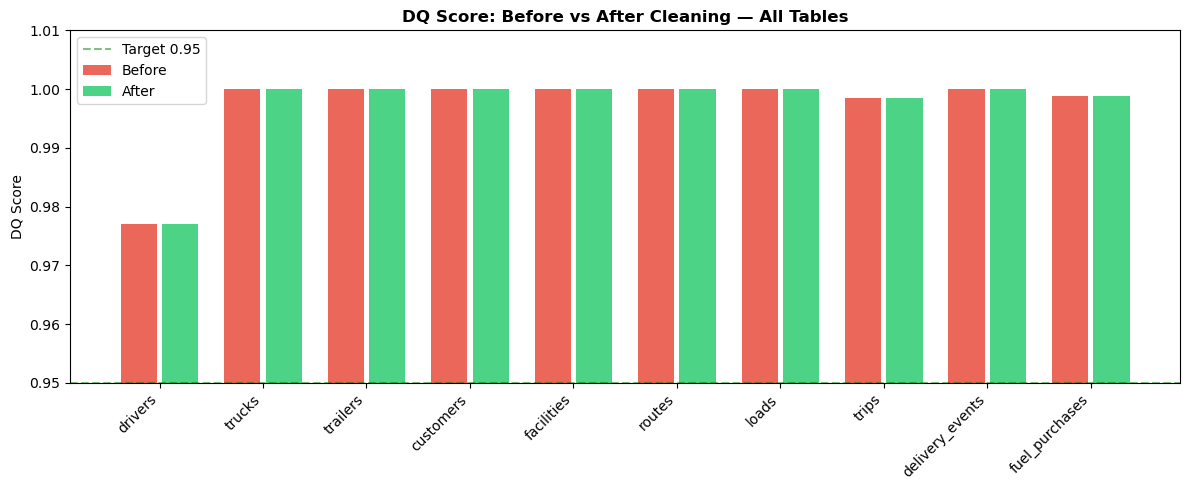

In [98]:
# ─────────────────────────────────────────────────────────────────────────────
# Before/After DQ Score Comparison
# Using quick_dq_score to show cleaning ROI across all tables
# ─────────────────────────────────────────────────────────────────────────────

# Map original dataframes to their cleaned versions
table_pairs = {
    'drivers'        : (drivers,         pipe_drivers.clean_df,         'driver_id',        [], []),
    'trucks'         : (trucks,          pipe_trucks.clean_df,           'truck_id',         [], []),
    'trailers'       : (trailers,        pipe_trailers.clean_df,         'trailer_id',       [], []),
    'customers'      : (customers,       pipe_customers.clean_df,        'customer_id',      [], []),
    'facilities'     : (facilities,      pipe_facilities.clean_df,       'facility_id',      [], []),
    'routes'         : (routes,          pipe_routes.clean_df,           'route_id',         ['typical_distance_miles','base_rate_per_mile','fuel_surcharge_rate','typical_transit_days'], []),
    'loads'          : (loads,           pipe_loads.clean_df,            'load_id',          ['revenue','weight_lbs','fuel_surcharge','accessorial_charges'], []),
    'trips'          : (trips,           pipe_trips.clean_df,            'trip_id',          ['actual_distance_miles','fuel_gallons_used','actual_duration_hours','average_mpg','idle_time_hours'], []),
    'delivery_events': (delivery_events, pipe_delivery_events.clean_df,  'event_id',         ['detention_minutes'], []),
    'fuel_purchases' : (fuel_purchases,  pipe_fuel_purchases.clean_df,   'fuel_purchase_id', ['gallons','price_per_gallon','total_cost'], []),
}

# Print before/after comparison for all tables
print(f"{'Table':<20} {'Before':>8} {'After':>8} {'Delta':>8}")
print("─" * 45)

results = []
for name, (df_before, df_after, pk, num_cols, cat_cols) in table_pairs.items():
    before = quick_dq_score(df_before, pk, num_cols, cat_cols)
    after  = quick_dq_score(df_after,  pk, num_cols, cat_cols)
    avg_before = round(sum(before.values()) / len(before), 4)
    avg_after  = round(sum(after.values())  / len(after),  4)
    delta = avg_after - avg_before
    arrow = '⬆️' if delta > 0 else ('➡️' if delta == 0 else '⬇️')
    print(f"{name:<20} {avg_before:>8.4f} {avg_after:>8.4f} {delta:>+8.4f} {arrow}")
    results.append({'table': name, 'before': avg_before, 'after': avg_after})

# Plot before/after comparison
results_df = pd.DataFrame(results)
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
ax.bar(x - 0.2, results_df['before'], 0.35, label='Before', color='#e74c3c', alpha=0.85)
ax.bar(x + 0.2, results_df['after'],  0.35, label='After',  color='#2ecc71', alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(results_df['table'], rotation=45, ha='right')
ax.set_ylim(0.95, 1.01)
ax.axhline(0.95, color='green', linestyle='--', alpha=0.5, label='Target 0.95')
ax.set_ylabel('DQ Score')
ax.set_title('DQ Score: Before vs After Cleaning — All Tables', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

## 5. Build Dimension Tables
*Phase 1 reference: Section 1.4 — Star Schema, attribute tree editing Step 1 (pruning)*  
Column selection follows the pruning decisions documented in the attribute tree editing steps.

## 6. Build Fact Table
*Phase 1 reference: Section 1.4 — fact\_trips definition and glossary of measures*

### 6.1 Base joins
### 6.2 Pivot delivery\_events
*Phase 1 reference: Attribute tree editing Step 2 — pivoting and grafting of delivery\_events*

### 6.3 Aggregate fuel\_purchases
*Phase 1 reference: Attribute tree editing Step 4 — aggregation and grafting of fuel\_purchases*

### 6.4 Add dim\_date
*Phase 1 reference: Attribute tree editing Step 6 — promoting dispatch\_date to dim\_date*

### 6.5 Derived columns
*Phase 1 reference: Section 1.5 — Glossary of measures (derived measures section)*

---
# LOAD
---
## 7. Export to CSV
Export all final dimension and fact tables to `data/output/`.

---
## 8. Validation & Sanity Checks
Row count verification, referential integrity checks, and KPI spot checks.